6.時系列解析
<!-- タスク内容：基本的な気象情報（気温と湿度）と5つのセンサーの入力値から、大気汚染の測定値を時系列で予測) -->

構成
1.ライブラリのインポート
2.データの読み込み、前処理
3.EDA、
4.特徴量作成、
5.学習、評価、
6.テストデータの予測

1. ライブラリのインポート

In [1]:
import pandas as pd
print('pandas:',pd.__version__)
import seaborn as sns
print('seaborn:',sns.__version__)
import numpy as np
print('numpy:',np.__version__)
import japanize_matplotlib
print('japanize_matplotlib:1.1.3')
import matplotlib
print('matplotlib:',matplotlib.__version__)
import joblib
print('joblib:',joblib.__version__)
import sklearn
print('sklearn:',sklearn.__version__)
import sweetviz
print('sweetviz:',sweetviz.__version__)
import lightgbm as lgb
print('lightgbm: 2.2.1')
from tsfresh import extract_features
print('tsfresh:  0.18.0')
import xgboost as xgb
print('xgboost:1.6.1')
import catboost as cb
print('catboost:0.26.1')
import shap
print('shap:',shap.__version__)
import optuna
print('optuna:',optuna.__version__)
import tensorflow as tf
print('tensorflow:',tf.__version__)

pandas: 1.4.2
seaborn: 0.11.2
numpy: 1.21.5
japanize_matplotlib:1.1.3
matplotlib: 3.5.1
joblib: 0.14.1
sklearn: 1.0.2
sweetviz: 2.1.3
lightgbm: 2.2.1
tsfresh:  0.18.0
xgboost:1.6.1
catboost:0.26.1
shap: 0.41.0
optuna: 2.10.0
tensorflow: 2.9.2


In [2]:
#version不明
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_squared_log_error,mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR,LinearSVR
from sklearn.linear_model import Ridge,Lasso,LinearRegression,ElasticNet,RANSACRegressor,TheilSenRegressor,ARDRegression,HuberRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor,BaggingRegressor,GradientBoostingRegressor,VotingRegressor,StackingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
import matplotlib.cm as cm
from matplotlib.colors import Normalize
# from xgboost import XGBRegressor
import datetime
import os
import re


2.データの読み込み、前処理

In [5]:
Drive = os.getcwd()
Input = os.path.join(Drive, 'Input')
Output = os.path.join(Drive, 'Output')
Submission = os.path.join(Drive, "submission")
Picture = os.path.join(Drive, "pic")

In [6]:
#model_map　重たいので必要なければ閉じてください
Picture=os.path.join(Picture, "model_map.jpg")
from PIL import Image 
img = Image.open(Picture)
img.show() 

In [7]:
#読み込み
sample_submission=pd.read_csv(os.path.join(Input, "sample_submission.csv"))
train = pd.read_csv(os.path.join(Input, "train.csv"))
test = pd.read_csv(os.path.join(Input, "test.csv"))

3.EDA(EDA.ipynbで行った)

4.特徴量作成(EDA.ipynbで行った)

5.学習、評価

In [8]:
train.date_time = pd.to_datetime(train.date_time)
train=train.set_index('date_time')
#target:target_carbon_monoxide	target_benzene	target_nitrogen_oxides
features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides')]
X1 = train[features].copy()
y1 = train.target_carbon_monoxide.copy()
X2 = train[features].copy()
y2 = train.target_benzene.copy()
X3 = train[features].copy()
y3 = train.target_nitrogen_oxides.copy()

#時間軸:2010-03-10 18:00:00〜2011-01-01 00:00:00の期間
# 学習データを2010-03-10 18:00:00〜2010-12-01 00:00:00の期間としX_trainに入力する
X1_train = X1['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y1_train = y1['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X2_train = X2['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y2_train = y2['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X3_train = X3['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y3_train = y3['2010-03-10 18:00:00' : '2010-12-01 00:00:00']

# 検証データを2010-12-01 01:00:00以降としてとしてX_validに入力する
X1_valid = X1['2010-12-01 01:00:00' : ]
y1_valid = y1['2010-12-01 01:00:00' : ]
X2_valid = X2['2010-12-01 01:00:00' : ]
y2_valid = y2['2010-12-01 01:00:00' : ]
X3_valid = X3['2010-12-01 01:00:00' : ]
y3_valid = y3['2010-12-01 01:00:00' : ]

In [9]:
#評価関数の定義
def get_eval_score(y_true,y_pred):
    mae=mean_absolute_error(y_true, y_pred)
    mse=mean_squared_error(y_true, y_pred)
    rmse=np.sqrt(mse)
    r2score=r2_score(y_true, y_pred)
    rmsle=np.sqrt(mean_squared_log_error (y_true, y_pred))
    mape=np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    #誤差を測定する
    print(f" MAE={mae}")
    print(f" MSE={mse}")
    print(f" MAPE={mape}")
    #RMSEが小さければ小さいほど機械学習モデルの性能がよい
    print(f" RMSE={rmse}")
    print(f" RMSLE={rmsle}")
    #モデルの適合度合いを測定する
    print(f" R2={r2score}")

#残差プロット
#予測値と実際の値とのずれ
def residual_plot(y_train_pred,y_train,y_val_pred,y_val):
    plt.scatter(y_train_pred,y_train_pred - y_train,label="train")
    plt.scatter(y_val_pred,y_val_pred - y_val,label="val")
    plt.plot([0,50],[0,0],color="red")
    plt.xlabel("Pred")
    plt.ylabel("Pred-True")
    plt.title("Residual Plot")
    plt.legend()
    plt.show()

#0以下を0にする
def relu(x):
    relu = []
    for i in x: 
        if i < 0:
            relu.append(0)
        else:
            relu.append(i)
    return relu

#予測値と正解値を描写する関数
def True_Pred_map(pred_df):
    RMSE = np.sqrt(mean_squared_error(pred_df['true'], pred_df['pred']))
    RMSLE = np.sqrt(mean_squared_log_error(pred_df['true'], pred_df['pred']))
    R2 = r2_score(pred_df['true'], pred_df['pred']) 
    plt.figure(figsize=(8,8))
    ax = plt.subplot(111)
    ax.scatter('true', 'pred', data=pred_df)
    ax.set_xlabel('True Value', fontsize=15)
    ax.set_ylabel('Pred Value', fontsize=15)
    ax.set_xlim(pred_df.min().min()-0.1 , pred_df.max().max()+0.1)
    ax.set_ylim(pred_df.min().min()-0.1 , pred_df.max().max()+0.1)
    x = np.linspace(pred_df.min().min()-0.1, pred_df.max().max()+0.1, 2)
    y = x
    ax.plot(x,y,'r-')
    plt.text(0.1, 0.9, 'RMSLE = {}'.format(str(round(RMSLE, 5))), transform=ax.transAxes, fontsize=15)
    plt.text(0.1, 0.8, 'R^2 = {}'.format(str(round(R2, 5))), transform=ax.transAxes, fontsize=15)
 
random_state=0


#加重移動平均
def calc_wma(target):
    weights = np.arange(len(target)) + 1
    wma = np.sum(weights * target) / weights.sum()
    return wma

5.1 モデル作成(1巡目)検証期間の目的変数の予測値を予測する

5.1.1 CO(1巡目)

In [7]:
#読み込み
sample_submission=pd.read_csv(os.path.join(Input, "sample_submission.csv"))
train = pd.read_csv(os.path.join(Input, "train.csv"))
test = pd.read_csv(os.path.join(Input, "test.csv"))
train.date_time = pd.to_datetime(train.date_time)

train=train.set_index('date_time')

In [8]:
#温度、絶対湿度、相対湿度を加工する
#特徴量(ラグ特徴量)
train['deg_C_shift1']=train['deg_C'].shift(1)
train['deg_C_shift2']=train['deg_C'].shift(2)
train['relative_humidity_shift1']=train['relative_humidity'].shift(1)
train['relative_humidity_shift2']=train['relative_humidity'].shift(2)
train['absolute_humidity_shift1']=train['absolute_humidity'].shift(1)
train['absolute_humidity_shift2']=train['absolute_humidity'].shift(2)

#特徴量(ローリング特徴量)
train['deg_C_rolling3hour']=train['deg_C'].rolling(3).mean()
train['relative_humidity_rolling3hour']=train['relative_humidity'].rolling(3).mean()
train['absolute_humidity_rolling3hour']=train['absolute_humidity'].rolling(3).mean()
train['deg_C_rolling10days']=train['deg_C'].rolling(240).mean()
train['relative_humidity_rolling10days']=train['relative_humidity'].rolling(240).mean()
train['absolute_humidity_rolling10days']=train['absolute_humidity'].rolling(240).mean()
train['deg_C_rolling3hour_min']=train['deg_C'].rolling(3).min()
train['relative_humidity_rolling3hour_min']=train['relative_humidity'].rolling(3).min()
train['absolute_humidity_rolling3hour_min']=train['absolute_humidity'].rolling(3).min()
train['deg_C_rolling10days_min']=train['deg_C'].rolling(240).min()
train['relative_humidity_rolling10days_min']=train['relative_humidity'].rolling(240).min()
train['absolute_humidity_rolling10days_min']=train['absolute_humidity'].rolling(240).min()

train['deg_C_rolling3hour_max']=train['deg_C'].rolling(3).max()
train['relative_humidity_rolling3hour_max']=train['relative_humidity'].rolling(3).max()
train['absolute_humidity_rolling3hour_max']=train['absolute_humidity'].rolling(3).max()
train['deg_C_rolling10days_max']=train['deg_C'].rolling(240).max()
train['relative_humidity_rolling10days_max']=train['relative_humidity'].rolling(240).max()
train['absolute_humidity_rolling10days_max']=train['absolute_humidity'].rolling(240).max()

train['deg_C_ewm3hour']=train['deg_C'].ewm(span=3,adjust=False).mean()
train['relative_humidity_ewm3hour']=train['relative_humidity'].ewm(span=3,adjust=False).mean()
train['absolute_humidity_ewm3hour']=train['absolute_humidity'].ewm(span=3,adjust=False).mean()
train['deg_C_ewm10days']=train['deg_C'].ewm(span=240,adjust=False).mean()
train['relative_humidity_ewm10days']=train['relative_humidity'].ewm(span=240,adjust=False).mean()
train['absolute_humidity_ewm10days']=train['absolute_humidity'].ewm(span=240,adjust=False).mean()

train['deg_C_rolling3hour_minmax']=train['deg_C_rolling3hour_max']-train['deg_C_rolling3hour_min']
train['relative_humidity_rolling3hour_minmax']=train['relative_humidity_rolling3hour_max']-train['relative_humidity_rolling3hour_min']
train['absolute_humidity_rolling3hour_minmax']=train['absolute_humidity_rolling3hour_max']-train['absolute_humidity_rolling3hour_min']
train['deg_C_rolling10days_minmax']=train['deg_C_rolling10days_max']-train['deg_C_rolling10days_min']
train['relative_humidity_rolling10days_minmax']=train['relative_humidity_rolling10days_max']-train['relative_humidity_rolling10days_min']
train['absolute_humidity_rolling10days_minmax']=train['absolute_humidity_rolling10days_max']-train['absolute_humidity_rolling10days_min']

train['deg_C_wma3hour']=train['deg_C'].rolling(3).apply(calc_wma)
train['relative_humidity_wma3hour']=train['relative_humidity'].rolling(3).apply(calc_wma)
train['absolute_humidity_wma3hour']=train['absolute_humidity'].rolling(3).apply(calc_wma)
train['deg_C_wma10days']=train['deg_C'].rolling(240).apply(calc_wma)
train['relative_humidity_wma10days']=train['relative_humidity'].rolling(240).apply(calc_wma)
train['absolute_humidity_wma10days']=train['absolute_humidity'].rolling(240).apply(calc_wma)



drop_date_range_rolling=pd.date_range('2010-03-10 18:00:00','2010-03-20 16:00:00',freq='H')
train=train.drop(drop_date_range_rolling)

#外れ値処理
train=train.drop(index=['2010/9/12 16:00','2010/10/26 18:00','2010/11/23 18:00','2010/11/23 19:00','2010/11/22 10:00',\
                        '2010/12/10 5:00','2010/12/10 7:00','2010/12/10 10:00','2010/10/26 18:00'])
#異常値処理
drop_date_range_a=pd.date_range('2010-04-08 23:00:00','2010-04-10 00:00:00',freq='H')
drop_date_range_b=pd.date_range('2010/05/25  19:00:00','2010/05/26  0:00:00',freq='H')
drop_date_range_c=pd.date_range('2010/06/19  12:00:00','2010/06/21  03:00:00',freq='H')
drop_date_range_d=pd.date_range('2010/08/26  00:00:00','2010/08/28  06:00:00',freq='H')
drop_date_range_e=pd.date_range('2010/12/14  17:00:00','2010/12/17  19:00:00',freq='H')
# train=train.drop(drop_date_range_a)
train=train.drop(drop_date_range_b)
# train=train.drop(drop_date_range_c)
train=train.drop(drop_date_range_d)
train=train.drop(drop_date_range_e)


    #target:target_carbon_monoxide	target_benzene	target_nitrogen_oxides
# CO_features = [feature for feature in train.columns if feature not in ('target_carbon_monoxide','benzene_shift1','benzene_shift2','NOx_shift1','NOx_shift2',\
#     'benzene_rolling3hour','benzene_rolling10days','NOx_rolling3hour','NOx_rolling10days','benzene_rolling3hour_min','benzene_rolling10days_min','NOx_rolling3hour_min','NOx_rolling10days_min',\
#         'benzene_rolling3hour_max','benzene_rolling10days_max','NOx_rolling3hour_max','NOx_rolling10days_max','benzene_ewm3hour','benzene_ewm10days','NOx_ewm3hour','NOx_ewm10days')]
# benzene_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides','CO_shift1','CO_shift2','NOx_shift1','NOx_shift2',\
#     'CO_rolling3hour','CO_rolling10days','NOx_rolling3hour','NOx_rolling10days','CO_rolling3hour_min','CO_rolling10days_min','NOx_rolling3hour_min','NOx_rolling10days_min',\
#        'CO_rolling3hour_max','CO_rolling10days_max','NOx_rolling3hour_max','NOx_rolling10days_max','CO_ewm3hour','CO_ewm10days','NOx_ewm3hour','NOx_ewm10days')]
# NOx_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides','CO_shift1','CO_shift2','benzene_shift1','benzene_shift2',\
#     'CO_rolling3hour','CO_rolling10days','benzene_rolling3hour','benzene_rolling10days','CO_rolling3hour_min','CO_rolling10days_min','benzene_rolling3hour_min','benzene_rolling10days_min',\
#         'CO_rolling3hour_max','CO_rolling10days_max','benzene_rolling3hour_max','benzene_rolling10days_max','CO_ewm3hour','CO_ewm10days','benzene_ewm3hour','benzene_ewm10days')]

CO_features = [feature for feature in train.columns if feature not in ('target_carbon_monoxide')]
benzene_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides')]
NOx_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides')]


X1 = train[CO_features].copy()
y1 = train.target_carbon_monoxide.copy()
X2 = train[benzene_features].copy()
y2 = train.target_benzene.copy()
X3 = train[NOx_features].copy()
y3 = train.target_nitrogen_oxides.copy()

# 学習データを2010-03-10 18:00:00〜2010-12-01 00:00:00の期間としX_trainに入力する
X1_train = X1['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y1_train = y1['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X2_train = X2['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y2_train = y2['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X3_train = X3['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y3_train = y3['2010-03-10 18:00:00' : '2010-12-01 00:00:00']

# 検証データを2010-12-01 01:00:00以降としてとしてX_validに入力する
X1_valid = X1['2010-12-01 01:00:00' : ]
y1_valid = y1['2010-12-01 01:00:00' : ]
X2_valid = X2['2010-12-01 01:00:00' : ]
y2_valid = y2['2010-12-01 01:00:00' : ]
X3_valid = X3['2010-12-01 01:00:00' : ]
y3_valid = y3['2010-12-01 01:00:00' : ]


#benzene(予測値1)
extratrees_model=ExtraTreesRegressor(n_estimators=100,bootstrap = True, random_state = random_state)
extratrees_model.fit(
    X2_train, y2_train
)
# 予測
extratrees_train_pred = extratrees_model.predict(X2_train)
extratrees_train_pred=relu(extratrees_train_pred)
extratrees_benzene_val_pred = extratrees_model.predict(X2_valid)
extratrees_benzene_val_pred=relu(extratrees_benzene_val_pred)

#Nox(予測値1)
import optuna
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'rmse',
        'lambda_l1': trial.suggest_loguniform('lambda_l1', 1e-8, 10.0),
        'lambda_l2': trial.suggest_loguniform('lambda_l2', 1e-8, 10.0),
        'num_leaves': trial.suggest_int('num_leaves', 2, 10),
        'feature_fraction': trial.suggest_uniform('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100)
    }
    
    trn_data = lgb.Dataset(X3_train, label=y3_train)
    val_data = lgb.Dataset(X3_valid, label=y3_valid)
    
    bst = lgb.train(params, trn_data, 10000, valid_sets = [trn_data, val_data], verbose_eval=-1, early_stopping_rounds = 20) 
    preds = bst.predict(X3_valid)
    pred_labels = np.rint(preds)
    
    RMSE = np.sqrt(mean_squared_error(y3_valid, pred_labels))
    rmsle=np.sqrt(mean_squared_log_error (y3_valid, preds))
    
    pruning_callback = optuna.integration.LightGBMPruningCallback(trial, 'rmsle')
    return rmsle
if __name__ == "__main__":
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=100, timeout=1200)

    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))
    print("  Params: ")
    for key, value in trial.params.items():
        print("{}: {}".format(key, value))

Best_trial = study.best_trial.params
Best_trial['metric']={'rmse'}
print('params:',Best_trial)
#Optunaで最適化されたパラメータ
params = Best_trial
trn_data = lgb.Dataset(X3_train, label=y3_train)
val_data = lgb.Dataset(X3_valid, label=y3_valid)
#LightGBMのモデル構築
gbm = lgb.train(params, trn_data, 10000, valid_sets = [trn_data, val_data], verbose_eval=-1, early_stopping_rounds = 10) 
 
#モデル評価用データで予測値出力
lgbm_Nox_val_pred = gbm.predict(X3_valid)
lgbm_Nox_val_pred=relu(lgbm_Nox_val_pred)



#benzen(予測値1)とNOx(予測値1)を取り込む
X1_valid['target_benzene'] =extratrees_benzene_val_pred.copy()
X1_valid['target_nitrogen_oxides'] =lgbm_Nox_val_pred.copy()

#CO(予測値2)
extratrees_model=ExtraTreesRegressor(n_estimators=100,bootstrap = True, random_state = random_state)
extratrees_model.fit(
    X1_train, y1_train
)

extratrees_train_pred = extratrees_model.predict(X1_train)
extratrees_train_pred=relu(extratrees_train_pred)
extratrees_val_pred = extratrees_model.predict(X1_valid)
extratrees_val_pred=relu(extratrees_val_pred)

train2=train.copy()
train2.target_benzene['2010-12-01 01:00:00' : ]=extratrees_val_pred

[I 2022-11-23 09:31:58,066] A new study created in memory with name: no-name-39b347cd-3cfc-4ad4-bb61-a76059065280
[I 2022-11-23 09:31:58,135] Trial 0 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.0731290667488059e-05, 'lambda_l2': 0.000484805721528126, 'num_leaves': 5, 'feature_fraction': 0.6571850064041349, 'bagging_fraction': 0.6442592490439614, 'bagging_freq': 1, 'min_child_samples': 90}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:58,216] Trial 1 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.060805699630405975, 'lambda_l2': 0.12780635819090047, 'num_leaves': 7, 'feature_fraction': 0.5368949412283877, 'bagging_fraction': 0.9946771847338002, 'bagging_freq': 2, 'min_child_samples': 19}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:58,267] Trial 2 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 3.6373276789818227, 'lambda_l2': 6.073833056473159e-07, 'num_leaves': 6, 'feat

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:31:58,315] Trial 3 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 4.310511694050065e-07, 'lambda_l2': 2.1736602177640468e-05, 'num_leaves': 9, 'feature_fraction': 0.8624673214138946, 'bagging_fraction': 0.6936877455414631, 'bagging_freq': 6, 'min_child_samples': 49}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:58,365] Trial 4 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 5.652631885531945e-06, 'lambda_l2': 0.021247707188426654, 'num_leaves': 10, 'feature_fraction': 0.6999010940165475, 'bagging_fraction': 0.7027206720125947, 'bagging_freq': 5, 'min_child_samples': 49}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:58,409] Trial 5 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 8.950452931426554, 'lambda_l2': 0.04738934198548834, 'num_leaves': 6, 'feature_fraction': 0.7029206861943331, 'bagging_fraction': 0.8454861345305602, 'bagging_freq': 3, 'min_child_samples'

[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002162 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

[I 2022-11-23 09:31:58,498] Trial 7 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.6566697563851871e-06, 'lambda_l2': 2.2930502795481837e-05, 'num_leaves': 2, 'feature_fraction': 0.8243125143157886, 'bagging_fraction': 0.5216376426513396, 'bagging_freq': 5, 'min_child_samples': 79}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:58,540] Trial 8 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 6.043671613439179e-07, 'lambda_l2': 2.2993527625445993, 'num_leaves': 2, 'feature_fraction': 0.7489695889509012, 'bagging_fraction': 0.6315482543198538, 'bagging_freq': 2, 'min_child_samples': 36}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:58,585] Trial 9 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.1707675933153153, 'lambda_l2': 0.0003311113118386557, 'num_leaves': 2, 'feature_fraction': 0.7519453675866887, 'bagging_fraction': 0.896726873383981, 'bagging_freq': 5, 'min_child_samples'

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002586 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warni

[I 2022-11-23 09:31:58,697] Trial 11 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.002436143752184402, 'lambda_l2': 3.6900701232962283, 'num_leaves': 8, 'feature_fraction': 0.5421941334193915, 'bagging_fraction': 0.9817226630478235, 'bagging_freq': 1, 'min_child_samples': 7}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:58,754] Trial 12 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.014681453108315104, 'lambda_l2': 0.031571044141567854, 'num_leaves': 7, 'feature_fraction': 0.583935492763348, 'bagging_fraction': 0.7754113258998171, 'bagging_freq': 2, 'min_child_samples': 9}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:58,820] Trial 13 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.8987954670188654e-08, 'lambda_l2': 2.6647073850811876e-08, 'num_leaves': 5, 'feature_fraction': 0.5889048035152782, 'bagging_fraction': 0.9902381290960429, 'bagging_freq': 2, 'min_child_samples

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001377 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:31:58,875] Trial 14 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 2.922712695224882e-05, 'lambda_l2': 0.28316474718418144, 'num_leaves': 7, 'feature_fraction': 0.4758094779283631, 'bagging_fraction': 0.7547948315656462, 'bagging_freq': 1, 'min_child_samples': 26}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:58,940] Trial 15 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.03479448829330255, 'lambda_l2': 0.0038448432759288836, 'num_leaves': 4, 'feature_fraction': 0.63835535469602, 'bagging_fraction': 0.6030694731904245, 'bagging_freq': 3, 'min_child_samples': 37}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:59,003] Trial 16 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.0001049124021385136, 'lambda_l2': 5.280189334872869e-05, 'num_leaves': 8, 'feature_fraction': 0.4893453875416627, 'bagging_fraction': 0.4271607370549996, 'bagging_freq': 4, 'min_child_sample

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001731 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warni

[I 2022-11-23 09:31:59,072] Trial 17 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.983832891266952e-05, 'lambda_l2': 0.4945094275055952, 'num_leaves': 5, 'feature_fraction': 0.4087186267810146, 'bagging_fraction': 0.7370640478217034, 'bagging_freq': 1, 'min_child_samples': 39}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:59,139] Trial 18 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.0008321445403308046, 'lambda_l2': 0.002738035073417234, 'num_leaves': 4, 'feature_fraction': 0.6486277021851429, 'bagging_fraction': 0.60470723035747, 'bagging_freq': 3, 'min_child_samples': 40}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:59,205] Trial 19 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 7.30497909599596e-05, 'lambda_l2': 4.855977215674135e-05, 'num_leaves': 9, 'feature_fraction': 0.49575614710715965, 'bagging_fraction': 0.4226298818301285, 'bagging_freq': 4, 'min_child_sample

[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001452 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

[I 2022-11-23 09:31:59,265] Trial 20 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 3.459733738585808e-08, 'lambda_l2': 0.5872817312125144, 'num_leaves': 5, 'feature_fraction': 0.9980697817251993, 'bagging_fraction': 0.6854476270510399, 'bagging_freq': 1, 'min_child_samples': 56}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:59,332] Trial 21 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.0007471121239591165, 'lambda_l2': 0.0020235646422553915, 'num_leaves': 5, 'feature_fraction': 0.6422359315807936, 'bagging_fraction': 0.5421002244404903, 'bagging_freq': 2, 'min_child_samples': 41}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:59,396] Trial 22 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.005231215898224091, 'lambda_l2': 0.00011243864636145928, 'num_leaves': 3, 'feature_fraction': 0.6349648706004465, 'bagging_fraction': 0.4271590794339917, 'bagging_freq': 4, 'min_child_sam

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002331 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warni

[I 2022-11-23 09:31:59,464] Trial 23 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.4359179154456358e-08, 'lambda_l2': 3.2587393355473123e-06, 'num_leaves': 10, 'feature_fraction': 0.9462144976347152, 'bagging_fraction': 0.6737807370761403, 'bagging_freq': 7, 'min_child_samples': 76}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:59,526] Trial 24 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.0033673294127464e-07, 'lambda_l2': 0.004760506953405102, 'num_leaves': 5, 'feature_fraction': 0.818604685055316, 'bagging_fraction': 0.5393136732624007, 'bagging_freq': 1, 'min_child_samples': 58}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:59,579] Trial 25 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.004673173465281574, 'lambda_l2': 0.00018219100640665245, 'num_leaves': 3, 'feature_fraction': 0.6420636642013928, 'bagging_fraction': 0.47885306408611705, 'bagging_freq': 2, 'min_chi

[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002953 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

[I 2022-11-23 09:31:59,633] Trial 26 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.5479718552347885, 'lambda_l2': 2.57996761034717e-06, 'num_leaves': 3, 'feature_fraction': 0.94042566233672, 'bagging_fraction': 0.6498825757685033, 'bagging_freq': 7, 'min_child_samples': 81}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:59,696] Trial 27 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 9.424062086150885e-08, 'lambda_l2': 4.666634862631661e-06, 'num_leaves': 6, 'feature_fraction': 0.8500565838808969, 'bagging_fraction': 0.5492873110527058, 'bagging_freq': 6, 'min_child_samples': 72}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:59,759] Trial 28 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 4.6634186873560535e-06, 'lambda_l2': 0.00973399844125301, 'num_leaves': 3, 'feature_fraction': 0.7934326618983972, 'bagging_fraction': 0.4738731246906225, 'bagging_freq': 1, 'min_child_samples

[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[Li

[I 2022-11-23 09:31:59,818] Trial 29 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.17116710724167825, 'lambda_l2': 1.2449611622029294e-07, 'num_leaves': 3, 'feature_fraction': 0.7048387160254721, 'bagging_fraction': 0.807996935158246, 'bagging_freq': 6, 'min_child_samples': 80}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:59,882] Trial 30 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.2305531618513882e-07, 'lambda_l2': 3.3462170865107594e-06, 'num_leaves': 6, 'feature_fraction': 0.8852773868998517, 'bagging_fraction': 0.5706629729759289, 'bagging_freq': 6, 'min_child_samples': 68}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:31:59,939] Trial 31 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 2.1667016548842755e-06, 'lambda_l2': 9.347668769540626e-07, 'num_leaves': 3, 'feature_fraction': 0.8042471699383646, 'bagging_fraction': 0.6394827031004721, 'bagging_freq': 7, 'min_child

[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more 

[I 2022-11-23 09:32:00,003] Trial 32 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 5.695456407339114e-06, 'lambda_l2': 3.39491812414154e-08, 'num_leaves': 6, 'feature_fraction': 0.7058031289335489, 'bagging_fraction': 0.46585519422721916, 'bagging_freq': 6, 'min_child_samples': 73}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:00,072] Trial 33 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 2.430226275580068e-07, 'lambda_l2': 5.701103545898522e-08, 'num_leaves': 3, 'feature_fraction': 0.8983028004369062, 'bagging_fraction': 0.7992377789076457, 'bagging_freq': 6, 'min_child_samples': 65}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:00,138] Trial 34 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.3846794768025645e-06, 'lambda_l2': 2.739354852275833e-07, 'num_leaves': 4, 'feature_fraction': 0.7975219197274139, 'bagging_fraction': 0.727335949958494, 'bagging_freq': 7, 'min_child_

[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Early stopping, best iteration is:
[1]	training's rmse: 253.259	

[I 2022-11-23 09:32:00,214] Trial 35 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.00010005394365539762, 'lambda_l2': 0.0009496320779349495, 'num_leaves': 5, 'feature_fraction': 0.9781866939199503, 'bagging_fraction': 0.4088744438453777, 'bagging_freq': 2, 'min_child_samples': 47}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:00,277] Trial 36 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.0030469701243101594, 'lambda_l2': 0.07613019413665492, 'num_leaves': 5, 'feature_fraction': 0.6004388556396278, 'bagging_fraction': 0.5189977962005881, 'bagging_freq': 4, 'min_child_samples': 45}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:00,338] Trial 37 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.0006442633847044122, 'lambda_l2': 0.0001244689110036908, 'num_leaves': 5, 'feature_fraction': 0.6750949901364741, 'bagging_fraction': 0.6778631463036676, 'bagging_freq': 2, 'min_child_s

[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003704 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

[I 2022-11-23 09:32:00,402] Trial 38 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.008867991554957284, 'lambda_l2': 8.306360428248463e-06, 'num_leaves': 9, 'feature_fraction': 0.606601009641915, 'bagging_fraction': 0.4456622470192244, 'bagging_freq': 5, 'min_child_samples': 76}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:00,462] Trial 39 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.0436600754080486e-08, 'lambda_l2': 0.0008996866134058853, 'num_leaves': 10, 'feature_fraction': 0.5488795007471006, 'bagging_fraction': 0.5125726743770052, 'bagging_freq': 3, 'min_child_samples': 86}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:00,520] Trial 40 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 3.8240254528097526e-08, 'lambda_l2': 0.010625764197176013, 'num_leaves': 8, 'feature_fraction': 0.7429056363103226, 'bagging_fraction': 0.6730686483360386, 'bagging_freq': 5, 'min_child_

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warni

[I 2022-11-23 09:32:00,584] Trial 41 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.004165515172910893, 'lambda_l2': 0.00023443069161775608, 'num_leaves': 2, 'feature_fraction': 0.6560978416757505, 'bagging_fraction': 0.5026154472654872, 'bagging_freq': 1, 'min_child_samples': 85}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:00,635] Trial 42 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.6872317477344634, 'lambda_l2': 1.676826123943977e-06, 'num_leaves': 4, 'feature_fraction': 0.9104241400864478, 'bagging_fraction': 0.6455780372581463, 'bagging_freq': 7, 'min_child_samples': 77}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:00,695] Trial 43 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 2.246523163562072, 'lambda_l2': 1.4319094285217627e-05, 'num_leaves': 6, 'feature_fraction': 0.9524527456643012, 'bagging_fraction': 0.5709994905350184, 'bagging_freq': 7, 'min_child_sample

[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001968 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

[I 2022-11-23 09:32:00,800] Trial 45 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 6.498809376909573e-07, 'lambda_l2': 3.2742643045295315e-05, 'num_leaves': 6, 'feature_fraction': 0.8593181274587769, 'bagging_fraction': 0.5600678030765167, 'bagging_freq': 1, 'min_child_samples': 61}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:00,861] Trial 46 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 8.476966491773933, 'lambda_l2': 0.014390924065180472, 'num_leaves': 3, 'feature_fraction': 0.7689082636386627, 'bagging_fraction': 0.45421064995385846, 'bagging_freq': 1, 'min_child_samples': 90}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:00,922] Trial 47 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 7.441794237114609e-06, 'lambda_l2': 0.0002625441226871828, 'num_leaves': 2, 'feature_fraction': 0.8384470083831931, 'bagging_fraction': 0.48011315457667614, 'bagging_freq': 6, 'min_child_sa

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001441 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:00,985] Trial 48 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.4105044000847049, 'lambda_l2': 2.649927801409783e-07, 'num_leaves': 3, 'feature_fraction': 0.7058191623717314, 'bagging_fraction': 0.8910862559357795, 'bagging_freq': 6, 'min_child_samples': 100}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:01,087] Trial 49 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.843439452273613e-05, 'lambda_l2': 1.1143711636382539e-07, 'num_leaves': 2, 'feature_fraction': 0.7863531107119409, 'bagging_fraction': 0.8124644067648972, 'bagging_freq': 6, 'min_child_samples': 80}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:01,151] Trial 50 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 2.486147786688576e-07, 'lambda_l2': 8.630814376840995e-07, 'num_leaves': 7, 'feature_fraction': 0.8880377946554753, 'bagging_fraction': 0.5883818426825763, 'bagging_freq': 5, 'min_child_s

[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that me

[I 2022-11-23 09:32:01,213] Trial 51 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.9609281765073324e-06, 'lambda_l2': 4.0386764051089887e-07, 'num_leaves': 6, 'feature_fraction': 0.8749567020026535, 'bagging_fraction': 0.6168817343482106, 'bagging_freq': 6, 'min_child_samples': 91}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:01,268] Trial 52 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 5.210953828254803e-06, 'lambda_l2': 1.689917908058296e-08, 'num_leaves': 4, 'feature_fraction': 0.7153180420710679, 'bagging_fraction': 0.7154193476481296, 'bagging_freq': 6, 'min_child_samples': 90}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:01,325] Trial 53 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 3.978498010512521e-06, 'lambda_l2': 9.433883753463969e-08, 'num_leaves': 6, 'feature_fraction': 0.7304580073879151, 'bagging_fraction': 0.6332497119550348, 'bagging_freq': 7, 'min_chil

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:01,378] Trial 54 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 3.5349316189427484e-07, 'lambda_l2': 4.572035670509243e-08, 'num_leaves': 4, 'feature_fraction': 0.6839751402428675, 'bagging_fraction': 0.8018118595934314, 'bagging_freq': 6, 'min_child_samples': 66}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:01,437] Trial 55 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 9.457378473729075e-07, 'lambda_l2': 1.1467263896082235e-08, 'num_leaves': 7, 'feature_fraction': 0.8997760657407814, 'bagging_fraction': 0.7791339090012877, 'bagging_freq': 6, 'min_child_samples': 61}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:01,493] Trial 56 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.741600953474831e-06, 'lambda_l2': 1.0407461698718156e-06, 'num_leaves': 4, 'feature_fraction': 0.9179635971593301, 'bagging_fraction': 0.7262456558906865, 'bagging_freq': 7, 'min_chi

[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Early stopping, best iteration is:
[1]	training's rmse: 253.259	valid_1's rmse: 416.087
[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positiv

[I 2022-11-23 09:32:01,614] Trial 58 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.0001139315112713533, 'lambda_l2': 0.0006972865545877134, 'num_leaves': 5, 'feature_fraction': 0.9734340244866897, 'bagging_fraction': 0.4083855052337625, 'bagging_freq': 7, 'min_child_samples': 50}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:01,667] Trial 59 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.194809200055481e-05, 'lambda_l2': 2.247895166215135e-07, 'num_leaves': 4, 'feature_fraction': 0.9978781114625298, 'bagging_fraction': 0.9530308191490229, 'bagging_freq': 5, 'min_child_samples': 44}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:01,722] Trial 60 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.0002429680709675484, 'lambda_l2': 8.239668142037873, 'num_leaves': 5, 'feature_fraction': 0.5616006706214928, 'bagging_fraction': 0.4001323791230033, 'bagging_freq': 4, 'min_child_samp

[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

[I 2022-11-23 09:32:01,843] Trial 62 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.0011030457867834507, 'lambda_l2': 0.0625825034338644, 'num_leaves': 5, 'feature_fraction': 0.6130290959175885, 'bagging_fraction': 0.44063724443026725, 'bagging_freq': 2, 'min_child_samples': 43}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:01,901] Trial 63 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.007928921563300962, 'lambda_l2': 1.379092229498352e-05, 'num_leaves': 9, 'feature_fraction': 0.6055821088913084, 'bagging_fraction': 0.83755180848081, 'bagging_freq': 5, 'min_child_samples': 48}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:01,962] Trial 64 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.0017397885064156981, 'lambda_l2': 0.0006195691409333297, 'num_leaves': 10, 'feature_fraction': 0.5114509863633185, 'bagging_fraction': 0.49909184014042646, 'bagging_freq': 3, 'min_child_sam

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:02,016] Trial 65 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.000255010012401826, 'lambda_l2': 0.0015571279264190356, 'num_leaves': 9, 'feature_fraction': 0.5569272162501416, 'bagging_fraction': 0.5186480224397135, 'bagging_freq': 3, 'min_child_samples': 53}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:02,072] Trial 66 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.01604201380652498, 'lambda_l2': 0.006038944999788245, 'num_leaves': 8, 'feature_fraction': 0.5798918551784339, 'bagging_fraction': 0.4467298745687166, 'bagging_freq': 4, 'min_child_samples': 57}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:02,129] Trial 67 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 4.269090323220756e-08, 'lambda_l2': 0.07927545503725604, 'num_leaves': 10, 'feature_fraction': 0.4491306128738714, 'bagging_fraction': 0.6729554290078981, 'bagging_freq': 5, 'min_child_sampl

[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Early stopping, best iteration is:
[1]	training's rmse: 253.259	valid_1's rmse: 416.087
[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001435 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [

[I 2022-11-23 09:32:02,250] Trial 69 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.007297692570617e-08, 'lambda_l2': 0.1653317593642931, 'num_leaves': 8, 'feature_fraction': 0.6569321112326824, 'bagging_fraction': 0.5006347344988512, 'bagging_freq': 2, 'min_child_samples': 63}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:02,303] Trial 70 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.019780801795529872, 'lambda_l2': 9.294452386001186e-05, 'num_leaves': 10, 'feature_fraction': 0.6199839114371586, 'bagging_fraction': 0.6590583555783739, 'bagging_freq': 1, 'min_child_samples': 76}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:02,362] Trial 71 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.6873200334429427e-05, 'lambda_l2': 5.14491510736029e-07, 'num_leaves': 2, 'feature_fraction': 0.7714108717162595, 'bagging_fraction': 0.884707916358999, 'bagging_freq': 6, 'min_child_samp

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001507 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:02,422] Trial 72 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 8.643272316955452, 'lambda_l2': 1.6213497349963978e-08, 'num_leaves': 2, 'feature_fraction': 0.8306392516765576, 'bagging_fraction': 0.6075109689491236, 'bagging_freq': 6, 'min_child_samples': 100}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:02,479] Trial 73 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 7.516709340104354e-06, 'lambda_l2': 4.377052367363903e-07, 'num_leaves': 2, 'feature_fraction': 0.7685456231647159, 'bagging_fraction': 0.9189773791850177, 'bagging_freq': 6, 'min_child_samples': 90}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:02,545] Trial 74 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 3.207522695708188e-06, 'lambda_l2': 1.0369662537699882e-07, 'num_leaves': 7, 'feature_fraction': 0.7179373734605348, 'bagging_fraction': 0.6188000403494913, 'bagging_freq': 6, 'min_child_s

Early stopping, best iteration is:
[1]	training's rmse: 253.259	valid_1's rmse: 416.087
[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001797 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopp

[I 2022-11-23 09:32:02,666] Trial 76 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 4.026172420268123e-07, 'lambda_l2': 1.4965825902952655e-07, 'num_leaves': 7, 'feature_fraction': 0.7358102325894583, 'bagging_fraction': 0.8442400667618253, 'bagging_freq': 6, 'min_child_samples': 69}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:02,729] Trial 77 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 3.1940643515651493e-06, 'lambda_l2': 2.2179402768288188e-07, 'num_leaves': 6, 'feature_fraction': 0.7238208963599507, 'bagging_fraction': 0.8053080285439184, 'bagging_freq': 5, 'min_child_samples': 99}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:02,785] Trial 78 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 7.47598355443245e-07, 'lambda_l2': 1.026921302044123e-08, 'num_leaves': 7, 'feature_fraction': 0.868040478708826, 'bagging_fraction': 0.7742355420010446, 'bagging_freq': 6, 'min_child

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001799 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:02,848] Trial 79 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.2980870843058088e-06, 'lambda_l2': 1.2101298443890248e-06, 'num_leaves': 4, 'feature_fraction': 0.9172569498036779, 'bagging_fraction': 0.7102881347928096, 'bagging_freq': 7, 'min_child_samples': 95}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:02,904] Trial 80 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.0632342233133645e-06, 'lambda_l2': 3.850072163411696e-08, 'num_leaves': 4, 'feature_fraction': 0.6901456796200033, 'bagging_fraction': 0.7505463968264636, 'bagging_freq': 7, 'min_child_samples': 93}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:02,963] Trial 81 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 2.109313770557669e-07, 'lambda_l2': 2.8517469858655265e-08, 'num_leaves': 4, 'feature_fraction': 0.9538133104522767, 'bagging_fraction': 0.7237450870850561, 'bagging_freq': 7, 'min_ch

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warni

[I 2022-11-23 09:32:03,020] Trial 82 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 1.0512383572662082e-05, 'lambda_l2': 1.5919798493418028e-08, 'num_leaves': 4, 'feature_fraction': 0.9988338506167412, 'bagging_fraction': 0.7723510666544015, 'bagging_freq': 7, 'min_child_samples': 64}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:03,082] Trial 83 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 4.3337669168171085e-07, 'lambda_l2': 4.730341205569168e-08, 'num_leaves': 4, 'feature_fraction': 0.98005706290363, 'bagging_fraction': 0.9721235495363709, 'bagging_freq': 7, 'min_child_samples': 59}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:03,136] Trial 84 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 6.214191718941409e-05, 'lambda_l2': 4.0023127862753975, 'num_leaves': 5, 'feature_fraction': 0.9778692494747823, 'bagging_fraction': 0.4098572831834562, 'bagging_freq': 7, 'min_child_sa

[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more 

[I 2022-11-23 09:32:03,252] Trial 86 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.00020226548543561104, 'lambda_l2': 1.6062847379188128, 'num_leaves': 5, 'feature_fraction': 0.9684450747198498, 'bagging_fraction': 0.7379653225967011, 'bagging_freq': 4, 'min_child_samples': 52}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:03,310] Trial 87 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 4.9505119517252406e-05, 'lambda_l2': 0.0004648372469729438, 'num_leaves': 5, 'feature_fraction': 0.5668165588028452, 'bagging_fraction': 0.42869530253384736, 'bagging_freq': 3, 'min_child_samples': 45}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:03,368] Trial 88 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.00014797805747894654, 'lambda_l2': 1.4365949883477661e-05, 'num_leaves': 5, 'feature_fraction': 0.6273814143965734, 'bagging_fraction': 0.6990903062607143, 'bagging_freq': 2, 'min_chil

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001648 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warni

[I 2022-11-23 09:32:03,430] Trial 89 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.0012987394713734656, 'lambda_l2': 1.0043310555945728, 'num_leaves': 5, 'feature_fraction': 0.612329512092828, 'bagging_fraction': 0.9480847364175156, 'bagging_freq': 4, 'min_child_samples': 36}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:03,485] Trial 90 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.0004773501868832281, 'lambda_l2': 0.0005037750391833149, 'num_leaves': 5, 'feature_fraction': 0.5040860165404117, 'bagging_fraction': 0.8359490413597184, 'bagging_freq': 3, 'min_child_samples': 28}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:03,535] Trial 91 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.0012674036253046612, 'lambda_l2': 0.0015920001619599432, 'num_leaves': 10, 'feature_fraction': 0.5267354309323844, 'bagging_fraction': 0.4346988932192635, 'bagging_freq': 3, 'min_child_sam

[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more 

[I 2022-11-23 09:32:03,648] Trial 93 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.0002751457585559738, 'lambda_l2': 0.0012783728391874006, 'num_leaves': 9, 'feature_fraction': 0.5282013188421992, 'bagging_fraction': 0.407173524742974, 'bagging_freq': 4, 'min_child_samples': 55}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:03,702] Trial 94 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.001305205539688044, 'lambda_l2': 0.04546624220085028, 'num_leaves': 10, 'feature_fraction': 0.44442553551686537, 'bagging_fraction': 0.6564379983314462, 'bagging_freq': 4, 'min_child_samples': 34}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:03,760] Trial 95 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.05136458943156079, 'lambda_l2': 0.007480299763033149, 'num_leaves': 9, 'feature_fraction': 0.5577869835339485, 'bagging_fraction': 0.4825624621772183, 'bagging_freq': 4, 'min_child_sampl

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001325 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:03,814] Trial 96 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.1327664211813276, 'lambda_l2': 0.1647460303673525, 'num_leaves': 8, 'feature_fraction': 0.45440202718408873, 'bagging_fraction': 0.5010014130189365, 'bagging_freq': 3, 'min_child_samples': 48}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:03,871] Trial 97 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 4.734805236269168e-08, 'lambda_l2': 0.02432040769193892, 'num_leaves': 9, 'feature_fraction': 0.6606217972981794, 'bagging_fraction': 0.5318810842638454, 'bagging_freq': 3, 'min_child_samples': 52}. Best is trial 0 with value: 4.997298262518527.
[I 2022-11-23 09:32:03,927] Trial 98 finished with value: 4.997298262518527 and parameters: {'lambda_l1': 0.024030929044008865, 'lambda_l2': 0.12396033039277343, 'num_leaves': 10, 'feature_fraction': 0.6223701439076724, 'bagging_fraction': 0.49561750944469357, 'bagging_freq': 2, 'min_child_samples'

[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Early stopping, best iteration is:
[1]	training's rmse: 253.259	valid_1's rmse: 416.087
[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001883 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used fe


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


5.1.2 ベンゼン(1巡目)

In [9]:
#benzene (予測値1)
#読み込み
sample_submission=pd.read_csv(os.path.join(Input, "sample_submission.csv"))
train = pd.read_csv(os.path.join(Input, "train.csv"))
test = pd.read_csv(os.path.join(Input, "test.csv"))

train.date_time = pd.to_datetime(train.date_time)
train=train.set_index('date_time')



#特徴量(ラグ特徴量)
train['deg_C_shift1']=train['deg_C'].shift(1)
train['deg_C_shift2']=train['deg_C'].shift(2)
train['relative_humidity_shift1']=train['relative_humidity'].shift(1)
train['relative_humidity_shift2']=train['relative_humidity'].shift(2)
train['absolute_humidity_shift1']=train['absolute_humidity'].shift(1)
train['absolute_humidity_shift2']=train['absolute_humidity'].shift(2)

#特徴量(ローリング特徴量)
train['deg_C_rolling3hour']=train['deg_C'].rolling(3).mean()
train['relative_humidity_rolling3hour']=train['relative_humidity'].rolling(3).mean()
train['absolute_humidity_rolling3hour']=train['absolute_humidity'].rolling(3).mean()
train['deg_C_rolling10days']=train['deg_C'].rolling(240).mean()
train['relative_humidity_rolling10days']=train['relative_humidity'].rolling(240).mean()
train['absolute_humidity_rolling10days']=train['absolute_humidity'].rolling(240).mean()
train['deg_C_rolling3hour_min']=train['deg_C'].rolling(3).min()
train['relative_humidity_rolling3hour_min']=train['relative_humidity'].rolling(3).min()
train['absolute_humidity_rolling3hour_min']=train['absolute_humidity'].rolling(3).min()
train['deg_C_rolling10days_min']=train['deg_C'].rolling(240).min()
train['relative_humidity_rolling10days_min']=train['relative_humidity'].rolling(240).min()
train['absolute_humidity_rolling10days_min']=train['absolute_humidity'].rolling(240).min()

train['deg_C_rolling3hour_max']=train['deg_C'].rolling(3).max()
train['relative_humidity_rolling3hour_max']=train['relative_humidity'].rolling(3).max()
train['absolute_humidity_rolling3hour_max']=train['absolute_humidity'].rolling(3).max()
train['deg_C_rolling10days_max']=train['deg_C'].rolling(240).max()
train['relative_humidity_rolling10days_max']=train['relative_humidity'].rolling(240).max()
train['absolute_humidity_rolling10days_max']=train['absolute_humidity'].rolling(240).max()

train['deg_C_ewm3hour']=train['deg_C'].ewm(span=3,adjust=False).mean()
train['relative_humidity_ewm3hour']=train['relative_humidity'].ewm(span=3,adjust=False).mean()
train['absolute_humidity_ewm3hour']=train['absolute_humidity'].ewm(span=3,adjust=False).mean()
train['deg_C_ewm10days']=train['deg_C'].ewm(span=240,adjust=False).mean()
train['relative_humidity_ewm10days']=train['relative_humidity'].ewm(span=240,adjust=False).mean()
train['absolute_humidity_ewm10days']=train['absolute_humidity'].ewm(span=240,adjust=False).mean()

train['deg_C_rolling3hour_minmax']=train['deg_C_rolling3hour_max']-train['deg_C_rolling3hour_min']
train['relative_humidity_rolling3hour_minmax']=train['relative_humidity_rolling3hour_max']-train['relative_humidity_rolling3hour_min']
train['absolute_humidity_rolling3hour_minmax']=train['absolute_humidity_rolling3hour_max']-train['absolute_humidity_rolling3hour_min']
train['deg_C_rolling10days_minmax']=train['deg_C_rolling10days_max']-train['deg_C_rolling10days_min']
train['relative_humidity_rolling10days_minmax']=train['relative_humidity_rolling10days_max']-train['relative_humidity_rolling10days_min']
train['absolute_humidity_rolling10days_minmax']=train['absolute_humidity_rolling10days_max']-train['absolute_humidity_rolling10days_min']

train['deg_C_wma3hour']=train['deg_C'].rolling(3).apply(calc_wma)
train['relative_humidity_wma3hour']=train['relative_humidity'].rolling(3).apply(calc_wma)
train['absolute_humidity_wma3hour']=train['absolute_humidity'].rolling(3).apply(calc_wma)
train['deg_C_wma10days']=train['deg_C'].rolling(240).apply(calc_wma)
train['relative_humidity_wma10days']=train['relative_humidity'].rolling(240).apply(calc_wma)
train['absolute_humidity_wma10days']=train['absolute_humidity'].rolling(240).apply(calc_wma)


drop_date_range_rolling=pd.date_range('2010-03-10 18:00:00','2010-03-20 16:00:00',freq='H')
train=train.drop(drop_date_range_rolling)

#外れ値処理
train=train.drop(index=['2010/9/12 16:00','2010/10/26 18:00','2010/11/23 18:00','2010/11/23 19:00','2010/11/22 10:00',\
                        '2010/12/10 5:00','2010/12/10 7:00','2010/12/10 10:00','2010/10/26 18:00'])
#異常値処理
drop_date_range_a=pd.date_range('2010-04-08 23:00:00','2010-04-10 00:00:00',freq='H')
drop_date_range_b=pd.date_range('2010/05/25  19:00:00','2010/05/26  0:00:00',freq='H')
drop_date_range_c=pd.date_range('2010/06/19  12:00:00','2010/06/21  03:00:00',freq='H')
drop_date_range_d=pd.date_range('2010/08/26  00:00:00','2010/08/28  06:00:00',freq='H')
drop_date_range_e=pd.date_range('2010/12/14  17:00:00','2010/12/17  19:00:00',freq='H')
# train=train.drop(drop_date_range_a)
train=train.drop(drop_date_range_b)
# train=train.drop(drop_date_range_c)
train=train.drop(drop_date_range_d)
train=train.drop(drop_date_range_e)


#target:target_carbon_monoxide	target_benzene	target_nitrogen_oxides

CO_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides')]
benzene_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides')]
NOx_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides')]

# CO_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides','benzene_shift1','benzene_shift2','NOx_shift1','NOx_shift2',\
#     'benzene_rolling3hour','benzene_rolling10days','NOx_rolling3hour','NOx_rolling10days','benzene_rolling3hour_min','benzene_rolling10days_min','NOx_rolling3hour_min','NOx_rolling10days_min',\
#         'benzene_rolling3hour_max','benzene_rolling10days_max','NOx_rolling3hour_max','NOx_rolling10days_max','benzene_ewm3hour','benzene_ewm10days','NOx_ewm3hour','NOx_ewm10days',\
#             'benzene_rolling3hour_minmax','benzene_rolling10days_minmax','NOx_rolling3hour_minmax','NOx_rolling10days_minmax')]
# benzene_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides','CO_shift1','CO_shift2','NOx_shift1','NOx_shift2',\
#     'CO_rolling3hour','CO_rolling10days','NOx_rolling3hour','NOx_rolling10days','CO_rolling3hour_min','CO_rolling10days_min','NOx_rolling3hour_min','NOx_rolling10days_min',\
#        'CO_rolling3hour_max','CO_rolling10days_max','NOx_rolling3hour_max','NOx_rolling10days_max','CO_ewm3hour','CO_ewm10days','NOx_ewm3hour','NOx_ewm10days',\
#         'CO_rolling3hour_minmax','CO_rolling10days_minmax','NOx_rolling3hour_minmax','NOx_rolling10days_minmax')]
# NOx_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides','CO_shift1','CO_shift2','benzene_shift1','benzene_shift2',\
#     'CO_rolling3hour','CO_rolling10days','benzene_rolling3hour','benzene_rolling10days','CO_rolling3hour_min','CO_rolling10days_min','benzene_rolling3hour_min','benzene_rolling10days_min',\
#         'CO_rolling3hour_max','CO_rolling10days_max','benzene_rolling3hour_max','benzene_rolling10days_max','CO_ewm3hour','CO_ewm10days','benzene_ewm3hour','benzene_ewm10days',\
#             'CO_rolling3hour_minmax','CO_rolling10days_minmax','benzene_rolling3hour_minmax','benzene_rolling10days_minmax')]
    
X1 = train[CO_features].copy()
y1 = train.target_carbon_monoxide.copy()
X2 = train[benzene_features].copy()
y2 = train.target_benzene.copy()
X3 = train[NOx_features].copy()
y3 = train.target_nitrogen_oxides.copy()


# 学習データを2010-03-10 18:00:00〜2010-12-01 00:00:00の期間としX_trainに入力する
X1_train = X1['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y1_train = y1['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X2_train = X2['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y2_train = y2['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X3_train = X3['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y3_train = y3['2010-03-10 18:00:00' : '2010-12-01 00:00:00']

# 検証データを2010-12-01 01:00:00以降としてとしてX_validに入力する
X1_valid = X1['2010-12-01 01:00:00' : ]
y1_valid = y1['2010-12-01 01:00:00' : ]
X2_valid = X2['2010-12-01 01:00:00' : ]
y2_valid = y2['2010-12-01 01:00:00' : ]
X3_valid = X3['2010-12-01 01:00:00' : ]
y3_valid = y3['2010-12-01 01:00:00' : ]

#ベンゼン(予測値1)
randomforest_model=RandomForestRegressor(random_state = random_state)
randomforest_model.fit(
    X2_train, y2_train
)
# 予測
randomforest_train_pred = randomforest_model.predict(X2_train)
randomforest_train_pred=relu(randomforest_train_pred)
randomforest_benzene_val_pred = randomforest_model.predict(X2_valid)
randomforest_benzene_val_pred=relu(randomforest_benzene_val_pred)
train2.target_benzene['2010-12-01 01:00:00' : ]=randomforest_benzene_val_pred

5.1.3 NOx(1巡目)

In [10]:
#読み込み

sample_submission=pd.read_csv(os.path.join(Input, "sample_submission.csv"))
train = pd.read_csv(os.path.join(Input, "train.csv"))
test = pd.read_csv(os.path.join(Input, "test.csv"))

train.date_time = pd.to_datetime(train.date_time)
train=train.set_index('date_time')



#特徴量(ラグ特徴量)
train['deg_C_shift1']=train['deg_C'].shift(1)
train['deg_C_shift2']=train['deg_C'].shift(2)
train['relative_humidity_shift1']=train['relative_humidity'].shift(1)
train['relative_humidity_shift2']=train['relative_humidity'].shift(2)
train['absolute_humidity_shift1']=train['absolute_humidity'].shift(1)
train['absolute_humidity_shift2']=train['absolute_humidity'].shift(2)

#特徴量(ローリング特徴量)
train['deg_C_rolling3hour']=train['deg_C'].rolling(3).mean()
train['relative_humidity_rolling3hour']=train['relative_humidity'].rolling(3).mean()
train['absolute_humidity_rolling3hour']=train['absolute_humidity'].rolling(3).mean()
train['deg_C_rolling10days']=train['deg_C'].rolling(240).mean()
train['relative_humidity_rolling10days']=train['relative_humidity'].rolling(240).mean()
train['absolute_humidity_rolling10days']=train['absolute_humidity'].rolling(240).mean()
train['deg_C_rolling3hour_min']=train['deg_C'].rolling(3).min()
train['relative_humidity_rolling3hour_min']=train['relative_humidity'].rolling(3).min()
train['absolute_humidity_rolling3hour_min']=train['absolute_humidity'].rolling(3).min()
train['deg_C_rolling10days_min']=train['deg_C'].rolling(240).min()
train['relative_humidity_rolling10days_min']=train['relative_humidity'].rolling(240).min()
train['absolute_humidity_rolling10days_min']=train['absolute_humidity'].rolling(240).min()

train['deg_C_rolling3hour_max']=train['deg_C'].rolling(3).max()
train['relative_humidity_rolling3hour_max']=train['relative_humidity'].rolling(3).max()
train['absolute_humidity_rolling3hour_max']=train['absolute_humidity'].rolling(3).max()
train['deg_C_rolling10days_max']=train['deg_C'].rolling(240).max()
train['relative_humidity_rolling10days_max']=train['relative_humidity'].rolling(240).max()
train['absolute_humidity_rolling10days_max']=train['absolute_humidity'].rolling(240).max()

train['deg_C_ewm3hour']=train['deg_C'].ewm(span=3,adjust=False).mean()
train['relative_humidity_ewm3hour']=train['relative_humidity'].ewm(span=3,adjust=False).mean()
train['absolute_humidity_ewm3hour']=train['absolute_humidity'].ewm(span=3,adjust=False).mean()
train['deg_C_ewm10days']=train['deg_C'].ewm(span=240,adjust=False).mean()
train['relative_humidity_ewm10days']=train['relative_humidity'].ewm(span=240,adjust=False).mean()
train['absolute_humidity_ewm10days']=train['absolute_humidity'].ewm(span=240,adjust=False).mean()

train['deg_C_rolling3hour_minmax']=train['deg_C_rolling3hour_max']-train['deg_C_rolling3hour_min']
train['relative_humidity_rolling3hour_minmax']=train['relative_humidity_rolling3hour_max']-train['relative_humidity_rolling3hour_min']
train['absolute_humidity_rolling3hour_minmax']=train['absolute_humidity_rolling3hour_max']-train['absolute_humidity_rolling3hour_min']
train['deg_C_rolling10days_minmax']=train['deg_C_rolling10days_max']-train['deg_C_rolling10days_min']
train['relative_humidity_rolling10days_minmax']=train['relative_humidity_rolling10days_max']-train['relative_humidity_rolling10days_min']
train['absolute_humidity_rolling10days_minmax']=train['absolute_humidity_rolling10days_max']-train['absolute_humidity_rolling10days_min']

train['deg_C_wma3hour']=train['deg_C'].rolling(3).apply(calc_wma)
train['relative_humidity_wma3hour']=train['relative_humidity'].rolling(3).apply(calc_wma)
train['absolute_humidity_wma3hour']=train['absolute_humidity'].rolling(3).apply(calc_wma)
train['deg_C_wma10days']=train['deg_C'].rolling(240).apply(calc_wma)
train['relative_humidity_wma10days']=train['relative_humidity'].rolling(240).apply(calc_wma)
train['absolute_humidity_wma10days']=train['absolute_humidity'].rolling(240).apply(calc_wma)


drop_date_range_rolling=pd.date_range('2010-03-10 18:00:00','2010-03-20 16:00:00',freq='H')
train=train.drop(drop_date_range_rolling)

#外れ値処理
train=train.drop(index=['2010/9/12 16:00','2010/10/26 18:00','2010/11/23 18:00','2010/11/23 19:00','2010/11/22 10:00',\
                        '2010/12/10 5:00','2010/12/10 7:00','2010/12/10 10:00','2010/10/26 18:00'])
#異常値処理
drop_date_range_a=pd.date_range('2010-04-08 23:00:00','2010-04-10 00:00:00',freq='H')
drop_date_range_b=pd.date_range('2010/05/25  19:00:00','2010/05/26  0:00:00',freq='H')
drop_date_range_c=pd.date_range('2010/06/19  12:00:00','2010/06/21  03:00:00',freq='H')
drop_date_range_d=pd.date_range('2010/08/26  00:00:00','2010/08/28  06:00:00',freq='H')
drop_date_range_e=pd.date_range('2010/12/14  17:00:00','2010/12/17  19:00:00',freq='H')
# train=train.drop(drop_date_range_a)
train=train.drop(drop_date_range_b)
# train=train.drop(drop_date_range_c)
train=train.drop(drop_date_range_d)
train=train.drop(drop_date_range_e)


#target:target_carbon_monoxide	target_benzene	target_nitrogen_oxides

CO_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides')]
benzene_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides')]
NOx_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides')]

# CO_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides','benzene_shift1','benzene_shift2','NOx_shift1','NOx_shift2',\
#     'benzene_rolling3hour','benzene_rolling10days','NOx_rolling3hour','NOx_rolling10days','benzene_rolling3hour_min','benzene_rolling10days_min','NOx_rolling3hour_min','NOx_rolling10days_min',\
#         'benzene_rolling3hour_max','benzene_rolling10days_max','NOx_rolling3hour_max','NOx_rolling10days_max','benzene_ewm3hour','benzene_ewm10days','NOx_ewm3hour','NOx_ewm10days',\
#             'benzene_rolling3hour_minmax','benzene_rolling10days_minmax','NOx_rolling3hour_minmax','NOx_rolling10days_minmax')]
# benzene_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides','CO_shift1','CO_shift2','NOx_shift1','NOx_shift2',\
#     'CO_rolling3hour','CO_rolling10days','NOx_rolling3hour','NOx_rolling10days','CO_rolling3hour_min','CO_rolling10days_min','NOx_rolling3hour_min','NOx_rolling10days_min',\
#        'CO_rolling3hour_max','CO_rolling10days_max','NOx_rolling3hour_max','NOx_rolling10days_max','CO_ewm3hour','CO_ewm10days','NOx_ewm3hour','NOx_ewm10days',\
#         'CO_rolling3hour_minmax','CO_rolling10days_minmax','NOx_rolling3hour_minmax','NOx_rolling10days_minmax')]
# NOx_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides','CO_shift1','CO_shift2','benzene_shift1','benzene_shift2',\
#     'CO_rolling3hour','CO_rolling10days','benzene_rolling3hour','benzene_rolling10days','CO_rolling3hour_min','CO_rolling10days_min','benzene_rolling3hour_min','benzene_rolling10days_min',\
#         'CO_rolling3hour_max','CO_rolling10days_max','benzene_rolling3hour_max','benzene_rolling10days_max','CO_ewm3hour','CO_ewm10days','benzene_ewm3hour','benzene_ewm10days',\
#             'CO_rolling3hour_minmax','CO_rolling10days_minmax','benzene_rolling3hour_minmax','benzene_rolling10days_minmax')]

X1 = train[CO_features].copy()
y1 = train.target_carbon_monoxide.copy()
X2 = train[benzene_features].copy()
y2 = train.target_benzene.copy()
X3 = train[NOx_features].copy()
y3 = train.target_nitrogen_oxides.copy()


# 学習データを2010-03-10 18:00:00〜2010-12-01 00:00:00の期間としX_trainに入力する
X1_train = X1['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y1_train = y1['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X2_train = X2['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y2_train = y2['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X3_train = X3['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y3_train = y3['2010-03-10 18:00:00' : '2010-12-01 00:00:00']

# 検証データを2010-12-01 01:00:00以降としてとしてX_validに入力する
X1_valid = X1['2010-12-01 01:00:00' : ]
y1_valid = y1['2010-12-01 01:00:00' : ]
X2_valid = X2['2010-12-01 01:00:00' : ]
y2_valid = y2['2010-12-01 01:00:00' : ]
X3_valid = X3['2010-12-01 01:00:00' : ]
y3_valid = y3['2010-12-01 01:00:00' : ]
#CO(予測値1)
import optuna
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'rmse',
        'lambda_l1': trial.suggest_loguniform('lambda_l1', 1e-8, 10.0),
        'lambda_l2': trial.suggest_loguniform('lambda_l2', 1e-8, 10.0),
        'num_leaves': trial.suggest_int('num_leaves', 2, 10),
        'feature_fraction': trial.suggest_uniform('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100)
    }
    
    trn_data = lgb.Dataset(X1_train, label=y1_train)
    val_data = lgb.Dataset(X1_valid, label=y1_valid)
    
    bst = lgb.train(params, trn_data, 10000, valid_sets = [trn_data, val_data], verbose_eval=-1, early_stopping_rounds = 20) 
    preds = bst.predict(X1_valid)
    pred_labels = np.rint(preds)
    
    RMSE = np.sqrt(mean_squared_error(y1_valid, pred_labels))
    rmsle=np.sqrt(mean_squared_log_error (y1_valid, preds))
    
    pruning_callback = optuna.integration.LightGBMPruningCallback(trial, 'rmsle')
    return rmsle
if __name__ == "__main__":
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=100, timeout=1200)

    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))
    print("  Params: ")
    for key, value in trial.params.items():
        print("{}: {}".format(key, value))
Best_trial = study.best_trial.params
Best_trial['metric']={'rmse'}
print('params:',Best_trial)
#Optunaで最適化されたパラメータ
params = Best_trial
trn_data = lgb.Dataset(X1_train, label=y1_train)
val_data = lgb.Dataset(X1_valid, label=y1_valid)
#LightGBMのモデル構築
gbm = lgb.train(params, trn_data, 10000, valid_sets = [trn_data, val_data], verbose_eval=-1, early_stopping_rounds = 10) 
 
#モデル評価用データで予測値出力
lgbm_CO_val_pred = gbm.predict(X1_valid)
lgbm_CO_val_pred=relu(lgbm_CO_val_pred)



#benzene(予測値1)
randomforest_model=RandomForestRegressor(random_state = random_state)
randomforest_model.fit(
    X2_train, y2_train
)
# 予測
randomforest_train_pred = randomforest_model.predict(X2_train)
randomforest_train_pred=relu(randomforest_train_pred)
randomforest_benzene_val_pred = randomforest_model.predict(X2_valid)
randomforest_benzene_val_pred=relu(randomforest_benzene_val_pred)

#NOxを予測(ExtraTreesRegressor)
#target:target_carbon_monoxide	target_benzene	target_nitrogen_oxides
CO_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides')]
benzene_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides')]
NOx_features = [feature for feature in train.columns if feature not in ('target_nitrogen_oxides')]

# CO_features = [feature for feature in train.columns if feature not in ('target_carbon_monoxide','benzene_shift1','benzene_shift2','NOx_shift1','NOx_shift2',\
#     'benzene_rolling3hour','benzene_rolling10days','NOx_rolling3hour','NOx_rolling10days','benzene_rolling3hour_min','benzene_rolling10days_min','NOx_rolling3hour_min','NOx_rolling10days_min',\
#         'benzene_rolling3hour_max','benzene_rolling10days_max','NOx_rolling3hour_max','NOx_rolling10days_max','benzene_ewm3hour','benzene_ewm10days','NOx_ewm3hour','NOx_ewm10days',\
#             'benzene_rolling3hour_minmax','benzene_rolling10days_minmax','NOx_rolling3hour_minmax','NOx_rolling10days_minmax')]
# benzene_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides','CO_shift1','CO_shift2','NOx_shift1','NOx_shift2',\
#     'CO_rolling3hour','CO_rolling10days','NOx_rolling3hour','NOx_rolling10days','CO_rolling3hour_min','CO_rolling10days_min','NOx_rolling3hour_min','NOx_rolling10days_min',\
#         'CO_rolling3hour_max','CO_rolling10days_max','NOx_rolling3hour_max','NOx_rolling10days_max','CO_ewm3hour','CO_ewm10days','NOx_ewm3hour','NOx_ewm10days',\
#             'CO_rolling3hour_minmax','CO_rolling10days_minmax','NOx_rolling3hour_minmax','NOx_rolling10days_minmax')]
# NOx_features = [feature for feature in train.columns if feature not in ('target_nitrogen_oxides','CO_shift1','CO_shift2','benzene_shift1','benzene_shift2',\
#     'CO_rolling3hour','CO_rolling10days','benzene_rolling3hour','benzene_rolling10days','CO_rolling3hour_min','CO_rolling10days_min','benzene_rolling3hour_min','benzene_rolling10days_min',\
#         'CO_rolling3hour_max','CO_rolling10days_max','benzene_rolling3hour_max','benzene_rolling10days_max','CO_ewm3hour','CO_ewm10days','benzene_ewm3hour','benzene_ewm10days',\
#             'CO_rolling3hour_minmax','CO_rolling10days_minmax','benzene_rolling3hour_minmax','benzene_rolling10days_minmax')]
# X1 = train[CO_features].copy()
y1 = train.target_carbon_monoxide.copy()
X2 = train[benzene_features].copy()
y2 = train.target_benzene.copy()
X3 = train[NOx_features].copy()
y3 = train.target_nitrogen_oxides.copy()
#時間軸:2010-03-10 18:00:00〜2011-01-01 00:00:00の期間
# 学習データを2010-03-10 18:00:00〜2010-12-01 00:00:00の期間としX_trainに入力する
X1_train = X1['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y1_train = y1['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X2_train = X2['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y2_train = y2['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X3_train = X3['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y3_train = y3['2010-03-10 18:00:00' : '2010-12-01 00:00:00']

# 検証データを2010-12-01 01:00:00以降としてとしてX_validに入力する
X1_valid = X1['2010-12-01 01:00:00' : ]
y1_valid = y1['2010-12-01 01:00:00' : ]
X2_valid = X2['2010-12-01 01:00:00' : ]
y2_valid = y2['2010-12-01 01:00:00' : ]
X3_valid = X3['2010-12-01 01:00:00' : ]
y3_valid = y3['2010-12-01 01:00:00' : ]

#CO (予測値1)とベンゼン (予測値1)を取り込む
X3_valid['target_carbon_monoxide'] =lgbm_CO_val_pred.copy()
X3_valid['target_benzene'] =randomforest_benzene_val_pred.copy()

#NOx(予測値2)
extratrees_model=ExtraTreesRegressor(n_estimators=100,bootstrap = True, random_state = random_state)
extratrees_model.fit(
    X3_train, y3_train
)
# 予測
extratrees_train_pred = extratrees_model.predict(X3_train)
extratrees_train_pred=relu(extratrees_train_pred)
extratrees_val_pred = extratrees_model.predict(X3_valid)
extratrees_val_pred=relu(extratrees_val_pred)

train2.target_nitrogen_oxides['2010-12-01 01:00:00' : ]=extratrees_val_pred

[I 2022-11-23 09:32:38,748] A new study created in memory with name: no-name-86ae75e0-7c1a-405d-9e15-ad1b3f9fb74d
[I 2022-11-23 09:32:38,814] Trial 0 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.02791748097486674, 'lambda_l2': 0.006594255715455238, 'num_leaves': 3, 'feature_fraction': 0.45537886689075974, 'bagging_fraction': 0.4073573834393434, 'bagging_freq': 6, 'min_child_samples': 42}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:38,862] Trial 1 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 5.529134834557214, 'lambda_l2': 1.0337671160428671e-08, 'num_leaves': 3, 'feature_fraction': 0.4939631455322843, 'bagging_fraction': 0.7071256826269765, 'bagging_freq': 2, 'min_child_samples': 64}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:38,928] Trial 2 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0017791285367443458, 'lambda_l2': 1.570251935406693e-08, 'num_leaves': 5,

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001643 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:39,041] Trial 4 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0668018364945721, 'lambda_l2': 0.760379241612115, 'num_leaves': 9, 'feature_fraction': 0.6374123711775067, 'bagging_fraction': 0.6569999064900243, 'bagging_freq': 3, 'min_child_samples': 60}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:39,099] Trial 5 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 6.075586513348987e-07, 'lambda_l2': 6.451577444123801, 'num_leaves': 3, 'feature_fraction': 0.42880185209121613, 'bagging_fraction': 0.6287524403302736, 'bagging_freq': 1, 'min_child_samples': 94}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:39,156] Trial 6 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.004572536015238582, 'lambda_l2': 1.828706416088156e-06, 'num_leaves': 6, 'feature_fraction': 0.76030604425936, 'bagging_fraction': 0.6211588798351542, 'bagging_freq': 4, 'min_child_samples': 7

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002037 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:39,215] Trial 7 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.000993573778601e-08, 'lambda_l2': 1.6145204839426538e-07, 'num_leaves': 7, 'feature_fraction': 0.42235645740344574, 'bagging_fraction': 0.9424310409045269, 'bagging_freq': 2, 'min_child_samples': 85}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:39,266] Trial 8 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 5.414267359634105, 'lambda_l2': 8.554060956557015e-08, 'num_leaves': 9, 'feature_fraction': 0.4642565476048911, 'bagging_fraction': 0.6504146933439379, 'bagging_freq': 2, 'min_child_samples': 13}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:39,317] Trial 9 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0002937620949663703, 'lambda_l2': 0.0029077682898595012, 'num_leaves': 6, 'feature_fraction': 0.5670085609620565, 'bagging_fraction': 0.7021038305865107, 'bagging_freq': 4, 'min_child_

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001836 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warni

[I 2022-11-23 09:32:39,423] Trial 11 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 9.842104947167355, 'lambda_l2': 0.00017454905619412566, 'num_leaves': 4, 'feature_fraction': 0.5399136893475328, 'bagging_fraction': 0.8162647034961853, 'bagging_freq': 6, 'min_child_samples': 42}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:39,475] Trial 12 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.20932051898557172, 'lambda_l2': 0.00707689740066078, 'num_leaves': 2, 'feature_fraction': 0.5378064787617656, 'bagging_fraction': 0.4046164706065943, 'bagging_freq': 7, 'min_child_samples': 49}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:39,530] Trial 13 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.7850249841691971, 'lambda_l2': 7.315871939612121e-06, 'num_leaves': 4, 'feature_fraction': 0.5051225758428328, 'bagging_fraction': 0.5018146114583303, 'bagging_freq': 5, 'min_child_sampl

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:39,642] Trial 15 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.011727157679204903, 'lambda_l2': 0.08786943157610311, 'num_leaves': 4, 'feature_fraction': 0.6206693228670968, 'bagging_fraction': 0.7749547301094029, 'bagging_freq': 6, 'min_child_samples': 67}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:39,691] Trial 16 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.9230905922277826, 'lambda_l2': 4.6646295404698706e-06, 'num_leaves': 2, 'feature_fraction': 0.4036948186658301, 'bagging_fraction': 0.536596700608055, 'bagging_freq': 3, 'min_child_samples': 24}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:39,746] Trial 17 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 5.932256857684784e-06, 'lambda_l2': 0.001815596653232144, 'num_leaves': 8, 'feature_fraction': 0.9591967736304101, 'bagging_fraction': 0.940021599428013, 'bagging_freq': 5, 'min_child_sam

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001563 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:39,860] Trial 19 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.4579670796720005, 'lambda_l2': 9.280419803478051e-06, 'num_leaves': 2, 'feature_fraction': 0.4008980133803788, 'bagging_fraction': 0.5135771495212617, 'bagging_freq': 3, 'min_child_samples': 22}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:39,911] Trial 20 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 4.7180771712212984e-06, 'lambda_l2': 0.0003792647811541476, 'num_leaves': 8, 'feature_fraction': 0.8582770126841627, 'bagging_fraction': 0.963370964688393, 'bagging_freq': 5, 'min_child_samples': 46}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:39,961] Trial 21 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 9.228187033893996e-07, 'lambda_l2': 0.060454598606899564, 'num_leaves': 10, 'feature_fraction': 0.7143116441457208, 'bagging_fraction': 0.8923237473721124, 'bagging_freq': 6, 'min_chil

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001054 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:40,074] Trial 23 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.1968523444854166e-08, 'lambda_l2': 6.252724368010632e-05, 'num_leaves': 8, 'feature_fraction': 0.8533026820446937, 'bagging_fraction': 0.9960535507326973, 'bagging_freq': 5, 'min_child_samples': 43}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:40,123] Trial 24 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 3.7136192915305856e-07, 'lambda_l2': 0.019701562219650835, 'num_leaves': 10, 'feature_fraction': 0.6982985668367232, 'bagging_fraction': 0.8798491380669639, 'bagging_freq': 6, 'min_child_samples': 42}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:40,178] Trial 25 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0006371534962790635, 'lambda_l2': 1.6272657367536028, 'num_leaves': 5, 'feature_fraction': 0.7245237165263274, 'bagging_fraction': 0.4584630971466404, 'bagging_freq': 7, 'min_ch

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001451 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:40,237] Trial 26 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.4490153024365312e-08, 'lambda_l2': 0.000313401964339976, 'num_leaves': 5, 'feature_fraction': 0.8339685390845922, 'bagging_fraction': 0.5602205064328423, 'bagging_freq': 7, 'min_child_samples': 34}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:40,288] Trial 27 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.1402488494129446e-07, 'lambda_l2': 0.021865763233895108, 'num_leaves': 10, 'feature_fraction': 0.8975209924643872, 'bagging_fraction': 0.9994147734866486, 'bagging_freq': 6, 'min_child_samples': 43}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:40,339] Trial 28 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.00013837646420557822, 'lambda_l2': 0.74497484205364, 'num_leaves': 5, 'feature_fraction': 0.6923635602357244, 'bagging_fraction': 0.4427366425496755, 'bagging_freq': 7, 'min_chil

[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Early stopping, best iteration is:
[1]	training's rmse: 1.71168	valid_1's rmse: 2.14695
[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001463 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> ini

[I 2022-11-23 09:32:40,457] Trial 30 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 6.188766505407656e-08, 'lambda_l2': 0.008830540686347067, 'num_leaves': 7, 'feature_fraction': 0.9103835909984584, 'bagging_fraction': 0.7444046917034917, 'bagging_freq': 6, 'min_child_samples': 36}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:40,511] Trial 31 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 6.816864125514534e-08, 'lambda_l2': 0.3267211740238295, 'num_leaves': 7, 'feature_fraction': 0.917266440662372, 'bagging_fraction': 0.4480021703254759, 'bagging_freq': 7, 'min_child_samples': 59}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:40,560] Trial 32 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 8.459104898981317e-05, 'lambda_l2': 0.2809819602438158, 'num_leaves': 5, 'feature_fraction': 0.8167467775852696, 'bagging_fraction': 0.4497172703472211, 'bagging_freq': 7, 'min_child_sam

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001445 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:40,672] Trial 34 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 6.995900630545668e-08, 'lambda_l2': 0.009380300469590153, 'num_leaves': 7, 'feature_fraction': 0.9401665454125865, 'bagging_fraction': 0.5747738858839766, 'bagging_freq': 7, 'min_child_samples': 61}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:40,729] Trial 35 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.6541821451316589e-06, 'lambda_l2': 2.750201177185042e-05, 'num_leaves': 9, 'feature_fraction': 0.4595787722696727, 'bagging_fraction': 0.9137435202780088, 'bagging_freq': 4, 'min_child_samples': 18}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:40,782] Trial 36 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 7.537964828438004e-06, 'lambda_l2': 4.3115665500383304, 'num_leaves': 8, 'feature_fraction': 0.6661714121200867, 'bagging_fraction': 0.8988235886317608, 'bagging_freq': 5, 'min_chil

[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002889 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

[I 2022-11-23 09:32:40,840] Trial 37 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 2.472553561300908e-05, 'lambda_l2': 9.256137312968693, 'num_leaves': 3, 'feature_fraction': 0.5885704101439421, 'bagging_fraction': 0.8546078375613271, 'bagging_freq': 5, 'min_child_samples': 72}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:40,899] Trial 38 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0022764984332699382, 'lambda_l2': 2.0366259876098245, 'num_leaves': 10, 'feature_fraction': 0.7352212947055785, 'bagging_fraction': 0.9852677018538284, 'bagging_freq': 4, 'min_child_samples': 85}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:40,955] Trial 39 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 2.3524218764930327e-07, 'lambda_l2': 6.849980946972643e-05, 'num_leaves': 9, 'feature_fraction': 0.5029409847493987, 'bagging_fraction': 0.4744828971331644, 'bagging_freq': 5, 'min_child_

[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that m

[I 2022-11-23 09:32:41,069] Trial 41 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0005042720553347779, 'lambda_l2': 1.5843155559338569, 'num_leaves': 6, 'feature_fraction': 0.739618197861814, 'bagging_fraction': 0.47333405129261275, 'bagging_freq': 6, 'min_child_samples': 100}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:41,132] Trial 42 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.015121105341845e-08, 'lambda_l2': 9.355358298766336e-05, 'num_leaves': 6, 'feature_fraction': 0.8245533626234653, 'bagging_fraction': 0.43371457004320424, 'bagging_freq': 7, 'min_child_samples': 38}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:41,188] Trial 43 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 5.037851762875703e-07, 'lambda_l2': 6.729632549105034e-07, 'num_leaves': 4, 'feature_fraction': 0.8555187232227061, 'bagging_fraction': 0.5924809645292721, 'bagging_freq': 6, 'min_ch

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001847 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:41,246] Trial 44 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 2.3834356521136375e-07, 'lambda_l2': 0.035135762031507735, 'num_leaves': 10, 'feature_fraction': 0.8089945892099535, 'bagging_fraction': 0.6228113442472301, 'bagging_freq': 7, 'min_child_samples': 40}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:41,304] Trial 45 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 3.313301099680571e-08, 'lambda_l2': 0.017392955685574026, 'num_leaves': 10, 'feature_fraction': 0.8800895433956027, 'bagging_fraction': 0.4068802887793162, 'bagging_freq': 6, 'min_child_samples': 46}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:41,361] Trial 46 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0001424565541746042, 'lambda_l2': 0.34280640733535905, 'num_leaves': 5, 'feature_fraction': 0.7602461014021081, 'bagging_fraction': 0.4312976511670464, 'bagging_freq': 7, 'min_ch

[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that m

[I 2022-11-23 09:32:41,461] Trial 48 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.021944389188893906, 'lambda_l2': 0.0005944298678829995, 'num_leaves': 5, 'feature_fraction': 0.778845021483992, 'bagging_fraction': 0.5394528729818505, 'bagging_freq': 1, 'min_child_samples': 31}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:41,519] Trial 49 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0031197366284881, 'lambda_l2': 0.004299658628281984, 'num_leaves': 6, 'feature_fraction': 0.7980767443979798, 'bagging_fraction': 0.56424304807491, 'bagging_freq': 7, 'min_child_samples': 32}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:41,579] Trial 50 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 3.0389072220536155, 'lambda_l2': 0.008361220432654764, 'num_leaves': 3, 'feature_fraction': 0.9120961477937132, 'bagging_fraction': 0.7381551880600307, 'bagging_freq': 6, 'min_child_samples

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001594 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:41,636] Trial 51 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 9.715494954904849e-08, 'lambda_l2': 0.6551942964512393, 'num_leaves': 7, 'feature_fraction': 0.9130968949574382, 'bagging_fraction': 0.4347802230738912, 'bagging_freq': 6, 'min_child_samples': 68}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:41,688] Trial 52 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 3.884419571448963e-05, 'lambda_l2': 0.4435878040563406, 'num_leaves': 7, 'feature_fraction': 0.9437758186040133, 'bagging_fraction': 0.4531903323009284, 'bagging_freq': 7, 'min_child_samples': 29}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:41,741] Trial 53 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.00010034139992660224, 'lambda_l2': 0.2006699767490427, 'num_leaves': 6, 'feature_fraction': 0.7628578936069573, 'bagging_fraction': 0.4183568205397794, 'bagging_freq': 7, 'min_child_sam

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001492 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warni

[I 2022-11-23 09:32:41,856] Trial 55 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.007479924671140557, 'lambda_l2': 0.00152105733489303, 'num_leaves': 7, 'feature_fraction': 0.9653580461140063, 'bagging_fraction': 0.7162178342784757, 'bagging_freq': 7, 'min_child_samples': 37}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:41,913] Trial 56 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 5.097122670029931e-08, 'lambda_l2': 0.003918148438792027, 'num_leaves': 7, 'feature_fraction': 0.9350784649423446, 'bagging_fraction': 0.6564825586021912, 'bagging_freq': 6, 'min_child_samples': 58}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:41,984] Trial 57 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 2.8013906874944794e-06, 'lambda_l2': 0.00789541894547246, 'num_leaves': 7, 'feature_fraction': 0.9256986964277247, 'bagging_fraction': 0.7939119344272647, 'bagging_freq': 7, 'min_child_

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001443 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:42,050] Trial 58 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.5520513432801345e-06, 'lambda_l2': 2.3890874747438885e-05, 'num_leaves': 9, 'feature_fraction': 0.4799271370308385, 'bagging_fraction': 0.5913887396074852, 'bagging_freq': 4, 'min_child_samples': 16}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:42,108] Trial 59 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.017482277212830778, 'lambda_l2': 0.00014918397049281504, 'num_leaves': 9, 'feature_fraction': 0.4284276953559987, 'bagging_fraction': 0.6409646760919053, 'bagging_freq': 4, 'min_child_samples': 63}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:42,160] Trial 60 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 8.176741479606131e-06, 'lambda_l2': 3.5758209833527004, 'num_leaves': 8, 'feature_fraction': 0.4473825903865094, 'bagging_fraction': 0.9063581049870273, 'bagging_freq': 5, 'min_ch

[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

[I 2022-11-23 09:32:42,290] Trial 62 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.101558307178448e-05, 'lambda_l2': 3.8644296314145268, 'num_leaves': 8, 'feature_fraction': 0.5653386829919562, 'bagging_fraction': 0.928204688096513, 'bagging_freq': 4, 'min_child_samples': 86}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:42,357] Trial 63 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.029314701234020482, 'lambda_l2': 1.7850894957810656e-05, 'num_leaves': 9, 'feature_fraction': 0.6627491335308088, 'bagging_fraction': 0.9778191897632571, 'bagging_freq': 4, 'min_child_samples': 71}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:42,414] Trial 64 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 2.0791558551163754e-07, 'lambda_l2': 3.2749763834909284e-06, 'num_leaves': 9, 'feature_fraction': 0.5038150519266851, 'bagging_fraction': 0.9596617642779317, 'bagging_freq': 5, 'min_chi

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001897 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:42,478] Trial 65 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.042914370298802e-06, 'lambda_l2': 3.6641990398583477, 'num_leaves': 9, 'feature_fraction': 0.4535805478610555, 'bagging_fraction': 0.9186942574188264, 'bagging_freq': 5, 'min_child_samples': 16}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:42,560] Trial 66 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 3.6298429459034735e-06, 'lambda_l2': 8.65215955671301, 'num_leaves': 9, 'feature_fraction': 0.661694826500674, 'bagging_fraction': 0.6769243482879652, 'bagging_freq': 4, 'min_child_samples': 78}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:42,631] Trial 67 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 3.875720723971374e-05, 'lambda_l2': 3.622191757033822e-05, 'num_leaves': 8, 'feature_fraction': 0.525155302962308, 'bagging_fraction': 0.8658739784445598, 'bagging_freq': 3, 'min_child_samp

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002667 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warni

[I 2022-11-23 09:32:42,729] Trial 68 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0005771557497758992, 'lambda_l2': 1.4955198750268701, 'num_leaves': 2, 'feature_fraction': 0.7325575663625534, 'bagging_fraction': 0.4958015109507339, 'bagging_freq': 5, 'min_child_samples': 81}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:42,805] Trial 69 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.002404474341337071, 'lambda_l2': 1.2211678160534383, 'num_leaves': 10, 'feature_fraction': 0.601338711283822, 'bagging_fraction': 0.8264613077788293, 'bagging_freq': 5, 'min_child_samples': 100}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:42,886] Trial 70 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 2.1138252985011598e-08, 'lambda_l2': 0.0001503770646281352, 'num_leaves': 6, 'feature_fraction': 0.7364111792592939, 'bagging_fraction': 0.4730841521119697, 'bagging_freq': 3, 'min_child_

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004575 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:42,994] Trial 71 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.2836973600892259, 'lambda_l2': 0.015233682356242225, 'num_leaves': 3, 'feature_fraction': 0.794636156646694, 'bagging_fraction': 0.4046512409312987, 'bagging_freq': 1, 'min_child_samples': 46}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:43,078] Trial 72 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.58555980814833, 'lambda_l2': 0.12096459690340876, 'num_leaves': 4, 'feature_fraction': 0.9655371159619642, 'bagging_fraction': 0.529344739896132, 'bagging_freq': 2, 'min_child_samples': 28}. Best is trial 0 with value: 0.6172048919370051.


[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002597 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because ther

[I 2022-11-23 09:32:43,172] Trial 73 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 4.112843249716225, 'lambda_l2': 0.5750324335979264, 'num_leaves': 3, 'feature_fraction': 0.9817310473142513, 'bagging_fraction': 0.5225387725249161, 'bagging_freq': 2, 'min_child_samples': 31}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:43,258] Trial 74 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.19994128606109418, 'lambda_l2': 0.004103800926579005, 'num_leaves': 6, 'feature_fraction': 0.8848144124400212, 'bagging_fraction': 0.41600969851492037, 'bagging_freq': 7, 'min_child_samples': 10}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:43,326] Trial 75 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.10047905380889677, 'lambda_l2': 0.1692898740595511, 'num_leaves': 4, 'feature_fraction': 0.7764059673607139, 'bagging_fraction': 0.5052174356778423, 'bagging_freq': 1, 'min_child_samples':

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002356 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:43,397] Trial 76 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.05473799007556175, 'lambda_l2': 0.0006577154609608406, 'num_leaves': 6, 'feature_fraction': 0.94708317909523, 'bagging_fraction': 0.7359849145553755, 'bagging_freq': 6, 'min_child_samples': 26}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:43,473] Trial 77 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0031342826383133487, 'lambda_l2': 0.07180421953752732, 'num_leaves': 6, 'feature_fraction': 0.8409147612071971, 'bagging_fraction': 0.7594101950615386, 'bagging_freq': 6, 'min_child_samples': 32}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:43,537] Trial 78 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.004655429470869145, 'lambda_l2': 0.0015584260576437731, 'num_leaves': 7, 'feature_fraction': 0.9677072895108596, 'bagging_fraction': 0.7174694423770647, 'bagging_freq': 7, 'min_child_sa

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001658 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:43,601] Trial 79 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.006541539993712259, 'lambda_l2': 0.0011512524594705937, 'num_leaves': 7, 'feature_fraction': 0.931247777213368, 'bagging_fraction': 0.7125567895404813, 'bagging_freq': 6, 'min_child_samples': 58}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:43,673] Trial 80 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0002411159022283418, 'lambda_l2': 0.0034129578316238716, 'num_leaves': 7, 'feature_fraction': 0.923751962623802, 'bagging_fraction': 0.8121516649232567, 'bagging_freq': 7, 'min_child_samples': 51}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:43,745] Trial 81 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 3.318892283789125e-06, 'lambda_l2': 0.0002307929697885897, 'num_leaves': 7, 'feature_fraction': 0.945157201091963, 'bagging_fraction': 0.7825946134752784, 'bagging_freq': 6, 'min_child

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002304 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warni

[I 2022-11-23 09:32:43,820] Trial 82 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.010893906952077823, 'lambda_l2': 0.002645048533916315, 'num_leaves': 8, 'feature_fraction': 0.48517736776597004, 'bagging_fraction': 0.6547772905833593, 'bagging_freq': 4, 'min_child_samples': 11}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:43,892] Trial 83 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.015769405696839687, 'lambda_l2': 0.00013133474064626316, 'num_leaves': 7, 'feature_fraction': 0.41386088482906624, 'bagging_fraction': 0.692361074947843, 'bagging_freq': 7, 'min_child_samples': 20}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:43,979] Trial 84 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.08537671967053112, 'lambda_l2': 0.00029021652854313405, 'num_leaves': 8, 'feature_fraction': 0.44803648148736575, 'bagging_fraction': 0.6061171824252282, 'bagging_freq': 4, 'min_ch

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001174 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:44,042] Trial 85 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0011981503897953191, 'lambda_l2': 0.0010094111425734738, 'num_leaves': 8, 'feature_fraction': 0.43343523989026383, 'bagging_fraction': 0.6412111307171026, 'bagging_freq': 4, 'min_child_samples': 9}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:44,106] Trial 86 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 2.212642616700125e-06, 'lambda_l2': 0.0050765022131361495, 'num_leaves': 8, 'feature_fraction': 0.4851907046340856, 'bagging_fraction': 0.6389654461131585, 'bagging_freq': 5, 'min_child_samples': 63}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:44,167] Trial 87 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 9.939506286438232e-06, 'lambda_l2': 3.789934876266758, 'num_leaves': 9, 'feature_fraction': 0.5373387532708825, 'bagging_fraction': 0.9212621052800142, 'bagging_freq': 4, 'min_child

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001147 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:44,231] Trial 88 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.2492731169106912e-05, 'lambda_l2': 2.109874139489788e-05, 'num_leaves': 9, 'feature_fraction': 0.565994016718312, 'bagging_fraction': 0.887682386636432, 'bagging_freq': 4, 'min_child_samples': 66}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:44,309] Trial 89 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.671965666186254e-05, 'lambda_l2': 1.8696404278852198e-05, 'num_leaves': 9, 'feature_fraction': 0.554864235944046, 'bagging_fraction': 0.9365156023728434, 'bagging_freq': 4, 'min_child_samples': 71}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:44,378] Trial 90 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 9.376770254942051e-07, 'lambda_l2': 2.9173306683178913e-06, 'num_leaves': 9, 'feature_fraction': 0.4733090397340299, 'bagging_fraction': 0.9690268193702476, 'bagging_freq': 4, 'min_c

[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

[I 2022-11-23 09:32:44,448] Trial 91 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.5593299128320118e-06, 'lambda_l2': 9.480020724847517e-07, 'num_leaves': 9, 'feature_fraction': 0.4399007454878466, 'bagging_fraction': 0.9596405654335034, 'bagging_freq': 5, 'min_child_samples': 16}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:44,510] Trial 92 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 4.892367137623611e-06, 'lambda_l2': 4.646761167728903, 'num_leaves': 9, 'feature_fraction': 0.50979816618714, 'bagging_fraction': 0.6767839469425253, 'bagging_freq': 5, 'min_child_samples': 78}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:44,581] Trial 93 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 9.954747009091594e-07, 'lambda_l2': 9.773969589606127, 'num_leaves': 9, 'feature_fraction': 0.6445211713365511, 'bagging_fraction': 0.9119864447970685, 'bagging_freq': 4, 'min_child_samp

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:44,648] Trial 94 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.030328305750145296, 'lambda_l2': 2.5597498451866034, 'num_leaves': 8, 'feature_fraction': 0.5175610534467648, 'bagging_fraction': 0.8517716608780165, 'bagging_freq': 3, 'min_child_samples': 88}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:44,713] Trial 95 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 3.9789024232936785e-05, 'lambda_l2': 1.0223539955389114, 'num_leaves': 2, 'feature_fraction': 0.5281505998539099, 'bagging_fraction': 0.9507517001355811, 'bagging_freq': 5, 'min_child_samples': 81}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:44,777] Trial 96 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0004348971366734187, 'lambda_l2': 9.54396907637062e-06, 'num_leaves': 10, 'feature_fraction': 0.6039196983715095, 'bagging_fraction': 0.8302843638697806, 'bagging_freq': 3, 'min_child_s

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001173 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM]

[I 2022-11-23 09:32:44,837] Trial 97 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 5.110411875895004e-05, 'lambda_l2': 1.0238272839360378, 'num_leaves': 2, 'feature_fraction': 0.5813503260253332, 'bagging_fraction': 0.8746827894705348, 'bagging_freq': 5, 'min_child_samples': 84}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:44,900] Trial 98 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.7387305758658454e-07, 'lambda_l2': 1.0363405955842831e-08, 'num_leaves': 10, 'feature_fraction': 0.6811722695363781, 'bagging_fraction': 0.9805086538022363, 'bagging_freq': 3, 'min_child_samples': 94}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:32:44,966] Trial 99 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.000824517957011229, 'lambda_l2': 1.2423033800848123e-05, 'num_leaves': 2, 'feature_fraction': 0.6246635250921492, 'bagging_fraction': 0.48786355240057144, 'bagging_freq': 3, 'min_

[LightGBM] [Info] Number of positive: 6062, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11350
[LightGBM] [Info] Number of data points in the train set: 6062, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


5.2 モデル作成(final model) 検証期間の目的変数を加工して特徴量に加える

In [11]:
#final
#特徴量(ラグ特徴量)
train2['CO_shift1']=train2['target_carbon_monoxide'].shift(1)
train2['CO_shift2']=train2['target_carbon_monoxide'].shift(2)
train2['benzene_shift1']=train2['target_benzene'].shift(1)
train2['benzene_shift2']=train2['target_benzene'].shift(2)
train2['NOx_shift1']=train2['target_nitrogen_oxides'].shift(1)
train2['NOx_shift2']=train2['target_nitrogen_oxides'].shift(2)

#特徴量(ローリング特徴量)
train2['CO_rolling3hour']=train2['target_carbon_monoxide'].rolling(3).mean()
train2['benzene_rolling3hour']=train2['target_benzene'].rolling(3).mean()
train2['NOx_rolling3hour']=train2['target_nitrogen_oxides'].rolling(3).mean()
train2['CO_rolling10days']=train2['target_carbon_monoxide'].rolling(240).mean()
train2['benzene_rolling10days']=train2['target_benzene'].rolling(240).mean()
train2['NOx_rolling10days']=train2['target_nitrogen_oxides'].rolling(240).mean()
train2['CO_rolling3hour_min']=train2['target_carbon_monoxide'].rolling(3).min()
train2['benzene_rolling3hour_min']=train2['target_benzene'].rolling(3).min()
train2['NOx_rolling3hour_min']=train2['target_nitrogen_oxides'].rolling(3).min()
train2['CO_rolling10days_min']=train2['target_carbon_monoxide'].rolling(240).min()
train2['benzene_rolling10days_min']=train2['target_benzene'].rolling(240).min()
train2['NOx_rolling10days_min']=train2['target_nitrogen_oxides'].rolling(240).min()

train2['CO_rolling3hour_max']=train2['target_carbon_monoxide'].rolling(3).max()
train2['benzene_rolling3hour_max']=train2['target_benzene'].rolling(3).max()
train2['NOx_rolling3hour_max']=train2['target_nitrogen_oxides'].rolling(3).max()
train2['CO_rolling10days_max']=train2['target_carbon_monoxide'].rolling(240).max()
train2['benzene_rolling10days_max']=train2['target_benzene'].rolling(240).max()
train2['NOx_rolling10days_max']=train2['target_nitrogen_oxides'].rolling(240).max()

train2['CO_ewm3hour']=train2['target_carbon_monoxide'].ewm(span=3,adjust=False).mean()
train2['benzene_ewm3hour']=train2['target_benzene'].ewm(span=3,adjust=False).mean()
train2['NOx_ewm3hour']=train2['target_nitrogen_oxides'].ewm(span=3,adjust=False).mean()
train2['CO_ewm10days']=train2['target_carbon_monoxide'].ewm(span=240,adjust=False).mean()
train2['benzene_ewm10days']=train2['target_benzene'].ewm(span=240,adjust=False).mean()
train2['NOx_ewm10days']=train2['target_nitrogen_oxides'].ewm(span=240,adjust=False).mean()

train2['CO_rolling3hour_minmax']=train2['CO_rolling3hour_max']-train2['CO_rolling3hour_min']
train2['benzene_rolling3hour_minmax']=train2['benzene_rolling3hour_max']-train2['benzene_rolling3hour_min']
train2['NOx_rolling3hour_minmax']=train2['NOx_rolling3hour_max']-train2['NOx_rolling3hour_min']
train2['CO_rolling10days_minmax']=train2['CO_rolling10days_max']-train2['CO_rolling10days_min']
train2['benzene_rolling10days_minmax']=train2['benzene_rolling10days_max']-train2['benzene_rolling10days_min']
train2['NOx_rolling10days_minmax']=train2['NOx_rolling10days_max']-train2['NOx_rolling10days_min']

train2['CO_wma3hour']=train2['target_carbon_monoxide'].rolling(3).apply(calc_wma)
train2['benzene_wma3hour']=train2['target_benzene'].rolling(3).apply(calc_wma)
train2['NOx_wma3hour']=train2['target_nitrogen_oxides'].rolling(3).apply(calc_wma)
train2['CO_wma10days']=train2['target_carbon_monoxide'].rolling(240).apply(calc_wma)
train2['benzene_wma10days']=train2['target_benzene'].rolling(240).apply(calc_wma)
train2['NOx_wma10days']=train2['target_nitrogen_oxides'].rolling(240).apply(calc_wma)



In [12]:
drop_date_range_rolling=pd.date_range('2010-03-20 17:00:00','2010-03-30 15:00:00',freq='H')
train2=train2.drop(drop_date_range_rolling)
train2.to_csv('train2.csv')

5.2.1 CO モデル作成(final model)

In [13]:
#CO final
train2=pd.read_csv('train2.csv')   
train2.date_time = pd.to_datetime(train2.date_time)
train2=train2.set_index('date_time')


CO_features = ['deg_C', 'relative_humidity', 'absolute_humidity', 'sensor_1','sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'target_benzene','target_nitrogen_oxides',\
    'CO_shift1','CO_shift2','CO_rolling3hour','CO_rolling10days', 'CO_rolling3hour_min', 'CO_rolling10days_min','CO_rolling3hour_max',\
       'CO_rolling10days_max','CO_ewm3hour', 'CO_ewm10days', 'CO_rolling3hour_minmax','CO_rolling10days_minmax', 'CO_wma3hour','CO_wma10days']
benzene_features = ['deg_C', 'relative_humidity', 'absolute_humidity', 'sensor_1','sensor_2', 'sensor_3', 'sensor_4', 'sensor_5']
NOx_features = ['deg_C', 'relative_humidity', 'absolute_humidity', 'sensor_1','sensor_2', 'sensor_3', 'sensor_4', 'sensor_5','target_benzene','target_carbon_monoxide']

X4 = train2[CO_features].copy()
y4 = train2.target_carbon_monoxide.copy()
X5 = train2[benzene_features].copy()
y5 = train2.target_benzene.copy()
X6 = train2[NOx_features].copy()
y6 = train2.target_nitrogen_oxides.copy()


# 学習データを2010-03-10 18:00:00〜2010-12-01 00:00:00の期間としX_trainに入力する
X4_train = X4['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y4_train = y4['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X5_train = X5['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y5_train = y5['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X6_train = X6['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y6_train = y6['2010-03-10 18:00:00' : '2010-12-01 00:00:00']

# 検証データを2010-12-01 01:00:00以降としてとしてX_validに入力する
X4_valid = X4['2010-12-01 01:00:00' : ]
y4_valid = y4['2010-12-01 01:00:00' : ]
X5_valid = X5['2010-12-01 01:00:00' : ]
y5_valid = y5['2010-12-01 01:00:00' : ]
X6_valid = X6['2010-12-01 01:00:00' : ]
y6_valid = y6['2010-12-01 01:00:00' : ]

#benzene(予測値1)
extratrees_model=ExtraTreesRegressor(n_estimators=100,bootstrap = True, random_state = random_state)
extratrees_model.fit(
    X5_train, y5_train
)
# 予測
extratrees_train_pred = extratrees_model.predict(X5_train)
extratrees_train_pred=relu(extratrees_train_pred)
extratrees_benzene_val_pred = extratrees_model.predict(X5_valid)
extratrees_benzene_val_pred=relu(extratrees_benzene_val_pred)


#NOx (予測値2)
import optuna
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'rmse',
        'lambda_l1': trial.suggest_loguniform('lambda_l1', 1e-8, 10.0),
        'lambda_l2': trial.suggest_loguniform('lambda_l2', 1e-8, 10.0),
        'num_leaves': trial.suggest_int('num_leaves', 2, 10),
        'feature_fraction': trial.suggest_uniform('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100)
    }
    
    trn_data = lgb.Dataset(X6_train, label=y6_train)
    val_data = lgb.Dataset(X6_valid, label=y6_valid)
    
    bst = lgb.train(params, trn_data, 10000, valid_sets = [trn_data, val_data], verbose_eval=-1, early_stopping_rounds = 20) 
    preds = bst.predict(X6_valid)
    pred_labels = np.rint(preds)
    
    RMSE = np.sqrt(mean_squared_error(y6_valid, pred_labels))
    rmsle=np.sqrt(mean_squared_log_error (y6_valid, preds))
    
    pruning_callback = optuna.integration.LightGBMPruningCallback(trial, 'rmsle')
    return rmsle
if __name__ == "__main__":
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=100, timeout=1200)

    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))
    print("  Params: ")
    for key, value in trial.params.items():
        print("{}: {}".format(key, value))

Best_trial = study.best_trial.params
Best_trial['metric']={'rmse'}
print('params:',Best_trial)
#Optunaで最適化されたパラメータ
params = Best_trial
trn_data = lgb.Dataset(X6_train, label=y6_train)
val_data = lgb.Dataset(X6_valid, label=y6_valid)
#LightGBMのモデル構築
gbm = lgb.train(params, trn_data, 10000, valid_sets = [trn_data, val_data], verbose_eval=-1, early_stopping_rounds = 10) 
 
#モデル評価用データで予測値出力
lgbm_Nox_val_pred = gbm.predict(X6_valid)
lgbm_Nox_val_pred=relu(lgbm_Nox_val_pred)

X4_valid['target_benzene'] =extratrees_benzene_val_pred.copy()
X4_valid['target_nitrogen_oxides'] =lgbm_Nox_val_pred.copy()


extratrees_model=ExtraTreesRegressor(n_estimators=100,bootstrap = True, random_state = random_state)
extratrees_model.fit(
    X4_train, y4_train
)
# 予測
extratrees_train_pred = extratrees_model.predict(X4_train)
extratrees_train_pred=relu(extratrees_train_pred)
extratrees_val_pred = extratrees_model.predict(X4_valid)
extratrees_val_pred=relu(extratrees_val_pred)

[I 2022-11-23 09:34:40,873] A new study created in memory with name: no-name-289ee942-2c5f-4e5e-b936-6517d4834ad7
[I 2022-11-23 09:34:40,930] Trial 0 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 4.442423943264195e-08, 'lambda_l2': 0.008797269233082376, 'num_leaves': 10, 'feature_fraction': 0.9749718432441183, 'bagging_fraction': 0.7433438688591598, 'bagging_freq': 7, 'min_child_samples': 12}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:40,964] Trial 1 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 4.992112245244271e-05, 'lambda_l2': 0.01954521869987975, 'num_leaves': 2, 'feature_fraction': 0.7039473092456445, 'bagging_fraction': 0.6807926782120326, 'bagging_freq': 1, 'min_child_samples': 34}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:40,996] Trial 2 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 1.0488318421078352e-06, 'lambda_l2': 0.10137826689611096, 'num_leaves': 8, 'f

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000833 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] 

[I 2022-11-23 09:34:41,105] Trial 5 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 1.7632914212379014, 'lambda_l2': 0.0013646341395149428, 'num_leaves': 4, 'feature_fraction': 0.8860383380777205, 'bagging_fraction': 0.9106773506796448, 'bagging_freq': 2, 'min_child_samples': 17}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:41,132] Trial 6 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 0.17564934824718356, 'lambda_l2': 0.2927677931422877, 'num_leaves': 4, 'feature_fraction': 0.40629092494913116, 'bagging_fraction': 0.9092925281691079, 'bagging_freq': 2, 'min_child_samples': 100}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:41,158] Trial 7 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 0.0008400173998169447, 'lambda_l2': 3.327943415008551e-06, 'num_leaves': 8, 'feature_fraction': 0.634079604620031, 'bagging_fraction': 0.5997382728121291, 'bagging_freq': 4, 'min_child_samples': 

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001563 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warnin

[I 2022-11-23 09:34:41,308] Trial 11 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 8.99981859820767e-06, 'lambda_l2': 0.008805582509274643, 'num_leaves': 2, 'feature_fraction': 0.8478659075456068, 'bagging_fraction': 0.7482844443488182, 'bagging_freq': 7, 'min_child_samples': 42}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:41,352] Trial 12 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 2.0997239093485547e-06, 'lambda_l2': 0.010310290757552644, 'num_leaves': 2, 'feature_fraction': 0.6735278632236661, 'bagging_fraction': 0.5652138043205508, 'bagging_freq': 6, 'min_child_samples': 36}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:41,409] Trial 13 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 0.0007356000273345787, 'lambda_l2': 3.7179982564584417, 'num_leaves': 5, 'feature_fraction': 0.826815081708261, 'bagging_fraction': 0.8001575560190735, 'bagging_freq': 4, 'min_child_sample

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000419 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] 

[I 2022-11-23 09:34:41,495] Trial 15 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 5.982983967726547e-05, 'lambda_l2': 0.0008663113386241523, 'num_leaves': 8, 'feature_fraction': 0.723224424691097, 'bagging_fraction': 0.5466816977713486, 'bagging_freq': 6, 'min_child_samples': 24}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:41,539] Trial 16 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 0.011448245589652503, 'lambda_l2': 8.950641391978419e-06, 'num_leaves': 6, 'feature_fraction': 0.9264383944667625, 'bagging_fraction': 0.8288599919006142, 'bagging_freq': 3, 'min_child_samples': 41}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:41,583] Trial 17 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 1.8614071939477756e-07, 'lambda_l2': 0.2267899311726972, 'num_leaves': 4, 'feature_fraction': 0.5263314483129479, 'bagging_fraction': 0.7298752901918505, 'bagging_freq': 3, 'min_child_samp

[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that m

[I 2022-11-23 09:34:41,709] Trial 20 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 2.2626953967998976e-07, 'lambda_l2': 0.3309308035032217, 'num_leaves': 4, 'feature_fraction': 0.40245614613116876, 'bagging_fraction': 0.7210216199459005, 'bagging_freq': 5, 'min_child_samples': 9}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:41,750] Trial 21 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 1.5325308868467383e-07, 'lambda_l2': 0.0023799542378348604, 'num_leaves': 9, 'feature_fraction': 0.978498956838487, 'bagging_fraction': 0.6143359532081543, 'bagging_freq': 6, 'min_child_samples': 25}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:41,790] Trial 22 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 0.004256284744327694, 'lambda_l2': 5.727965248295638e-06, 'num_leaves': 9, 'feature_fraction': 0.9177119120427261, 'bagging_fraction': 0.9778223421015098, 'bagging_freq': 7, 'min_child_sam

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000393 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] 

[I 2022-11-23 09:34:41,911] Trial 25 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 8.739824657645956, 'lambda_l2': 3.157786243375497e-05, 'num_leaves': 9, 'feature_fraction': 0.9632002273449862, 'bagging_fraction': 0.9890023959359109, 'bagging_freq': 7, 'min_child_samples': 82}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:41,949] Trial 26 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 1.3374434067743523e-08, 'lambda_l2': 1.4864888756110928e-07, 'num_leaves': 5, 'feature_fraction': 0.8749897723850384, 'bagging_fraction': 0.8546271257285155, 'bagging_freq': 7, 'min_child_samples': 67}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:41,996] Trial 27 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 6.080237330616592e-08, 'lambda_l2': 5.941877993798827e-07, 'num_leaves': 7, 'feature_fraction': 0.7773322457286068, 'bagging_fraction': 0.7705695520175752, 'bagging_freq': 5, 'min_child_sa

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000477 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] 

[I 2022-11-23 09:34:42,081] Trial 29 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 6.61362945061217, 'lambda_l2': 1.8632325575298437e-08, 'num_leaves': 7, 'feature_fraction': 0.8689414650702662, 'bagging_fraction': 0.8595810729021712, 'bagging_freq': 7, 'min_child_samples': 66}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:42,128] Trial 30 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 4.999018361732354e-08, 'lambda_l2': 4.934937921153984e-07, 'num_leaves': 7, 'feature_fraction': 0.765349108957399, 'bagging_fraction': 0.7689102712937508, 'bagging_freq': 6, 'min_child_samples': 45}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:42,180] Trial 31 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 5.252318557911404e-06, 'lambda_l2': 5.590446803863007e-07, 'num_leaves': 5, 'feature_fraction': 0.8197318319389018, 'bagging_fraction': 0.8204575820124198, 'bagging_freq': 7, 'min_child_sampl

[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more 

[I 2022-11-23 09:34:42,267] Trial 33 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 7.618539492931821, 'lambda_l2': 3.714260359326044e-08, 'num_leaves': 8, 'feature_fraction': 0.7288023590422261, 'bagging_fraction': 0.6657298575447186, 'bagging_freq': 6, 'min_child_samples': 63}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:42,329] Trial 34 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 2.5536115850315223e-06, 'lambda_l2': 9.777885589598022e-07, 'num_leaves': 6, 'feature_fraction': 0.7583029508006609, 'bagging_fraction': 0.8116199209399655, 'bagging_freq': 7, 'min_child_samples': 97}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:42,386] Trial 35 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 6.801908414604663e-07, 'lambda_l2': 0.8117481272417808, 'num_leaves': 3, 'feature_fraction': 0.9618217831582653, 'bagging_fraction': 0.717403508439265, 'bagging_freq': 4, 'min_child_samples

[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Early stopping, best iteration is:
[1]	training's rmse: 257.064	valid_1's rmse: 384.013
[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000550 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> init

[I 2022-11-23 09:34:42,498] Trial 37 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 0.003096133641645393, 'lambda_l2': 0.004482169324821929, 'num_leaves': 9, 'feature_fraction': 0.4687683841698436, 'bagging_fraction': 0.9585321582563584, 'bagging_freq': 6, 'min_child_samples': 15}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:42,549] Trial 38 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 1.1489062654940811e-08, 'lambda_l2': 2.6118652003684407e-05, 'num_leaves': 10, 'feature_fraction': 0.4491909042332037, 'bagging_fraction': 0.9390586024918809, 'bagging_freq': 5, 'min_child_samples': 76}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:42,587] Trial 39 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 2.3429079177130613e-05, 'lambda_l2': 0.00012718823960093867, 'num_leaves': 8, 'feature_fraction': 0.9052491932477209, 'bagging_fraction': 0.8888897835419037, 'bagging_freq': 6, 'min_chi

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000471 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] 

[I 2022-11-23 09:34:42,697] Trial 42 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 1.7509968482518654e-08, 'lambda_l2': 1.4947425394828454e-07, 'num_leaves': 5, 'feature_fraction': 0.895849504599738, 'bagging_fraction': 0.9344970848871125, 'bagging_freq': 6, 'min_child_samples': 69}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:42,735] Trial 43 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 7.358071470464784e-08, 'lambda_l2': 3.5199275824293174e-05, 'num_leaves': 5, 'feature_fraction': 0.5840559398214533, 'bagging_fraction': 0.8604102003220793, 'bagging_freq': 7, 'min_child_samples': 86}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:42,776] Trial 44 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 6.143384109885497e-07, 'lambda_l2': 5.805735080125005e-08, 'num_leaves': 8, 'feature_fraction': 0.7801763502058707, 'bagging_fraction': 0.7799325358633108, 'bagging_freq': 7, 'min_chil

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000384 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warnin

[I 2022-11-23 09:34:42,891] Trial 47 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 2.597844709406743, 'lambda_l2': 5.848972643471345e-05, 'num_leaves': 8, 'feature_fraction': 0.8791764250698081, 'bagging_fraction': 0.6867472646174049, 'bagging_freq': 7, 'min_child_samples': 93}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:42,929] Trial 48 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 0.2553258514449552, 'lambda_l2': 1.3484616927359727e-08, 'num_leaves': 7, 'feature_fraction': 0.8781658974041392, 'bagging_fraction': 0.4577775257091543, 'bagging_freq': 7, 'min_child_samples': 66}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:42,965] Trial 49 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 0.0002724159449152876, 'lambda_l2': 8.921002795262744e-08, 'num_leaves': 7, 'feature_fraction': 0.8596158868913761, 'bagging_fraction': 0.8453339740449748, 'bagging_freq': 7, 'min_child_sample

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000413 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warnin

[I 2022-11-23 09:34:43,078] Trial 52 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 0.23673489842424755, 'lambda_l2': 1.255221283330448e-08, 'num_leaves': 7, 'feature_fraction': 0.8540129876738447, 'bagging_fraction': 0.8074861528349379, 'bagging_freq': 7, 'min_child_samples': 88}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:43,123] Trial 53 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 1.0813391966472028, 'lambda_l2': 9.23384108323026, 'num_leaves': 6, 'feature_fraction': 0.8117778236824418, 'bagging_fraction': 0.494283755083457, 'bagging_freq': 7, 'min_child_samples': 94}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:43,159] Trial 54 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 9.606193957577279, 'lambda_l2': 4.6154327800634824e-08, 'num_leaves': 7, 'feature_fraction': 0.7395672735465525, 'bagging_fraction': 0.6615543883403758, 'bagging_freq': 6, 'min_child_samples': 59}.

[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000477 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are 

[I 2022-11-23 09:34:43,273] Trial 57 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 6.627687981030149e-05, 'lambda_l2': 2.49341503512441e-07, 'num_leaves': 8, 'feature_fraction': 0.7151062073768547, 'bagging_fraction': 0.5818093305867551, 'bagging_freq': 6, 'min_child_samples': 96}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:43,316] Trial 58 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 3.2947240894586645e-06, 'lambda_l2': 0.6337136412809956, 'num_leaves': 3, 'feature_fraction': 0.6504956700449415, 'bagging_fraction': 0.7158288828072757, 'bagging_freq': 4, 'min_child_samples': 32}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:43,357] Trial 59 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 2.015888347875529e-05, 'lambda_l2': 1.3804356378894618e-06, 'num_leaves': 3, 'feature_fraction': 0.951748160704984, 'bagging_fraction': 0.6986304014891986, 'bagging_freq': 4, 'min_child_sam

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000374 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warnin

[I 2022-11-23 09:34:43,471] Trial 62 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 1.9741299016635214e-06, 'lambda_l2': 1.165234119316292, 'num_leaves': 10, 'feature_fraction': 0.4501077696119578, 'bagging_fraction': 0.9602066271504069, 'bagging_freq': 5, 'min_child_samples': 12}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:43,516] Trial 63 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 7.803801773723971e-07, 'lambda_l2': 0.09878806171746062, 'num_leaves': 10, 'feature_fraction': 0.48986707336679797, 'bagging_fraction': 0.9373596087142666, 'bagging_freq': 5, 'min_child_samples': 11}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:43,555] Trial 64 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 1.5171019627162899e-05, 'lambda_l2': 0.003285898541406117, 'num_leaves': 10, 'feature_fraction': 0.9996036890116705, 'bagging_fraction': 0.9070369803714383, 'bagging_freq': 4, 'min_child_s

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000472 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] 

[I 2022-11-23 09:34:43,673] Trial 67 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 1.2219902357494968e-07, 'lambda_l2': 0.035379477988554224, 'num_leaves': 10, 'feature_fraction': 0.573638370635252, 'bagging_fraction': 0.9602379393338129, 'bagging_freq': 5, 'min_child_samples': 15}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:43,712] Trial 68 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 3.0475844739560266e-08, 'lambda_l2': 1.8173757335450632e-05, 'num_leaves': 9, 'feature_fraction': 0.4907025566861316, 'bagging_fraction': 0.9270112810516826, 'bagging_freq': 6, 'min_child_samples': 79}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:43,755] Trial 69 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 0.07414231860392417, 'lambda_l2': 9.010426513607627e-06, 'num_leaves': 9, 'feature_fraction': 0.6181170907805793, 'bagging_fraction': 0.9664261798979605, 'bagging_freq': 5, 'min_child_

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000777 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] 

[I 2022-11-23 09:34:43,872] Trial 72 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 0.02242935692871299, 'lambda_l2': 1.2085897480734069e-08, 'num_leaves': 7, 'feature_fraction': 0.8602935239735697, 'bagging_fraction': 0.40270182682050043, 'bagging_freq': 2, 'min_child_samples': 46}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:43,909] Trial 73 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 0.27367961501494487, 'lambda_l2': 8.584186415236662e-08, 'num_leaves': 7, 'feature_fraction': 0.8838017755155692, 'bagging_fraction': 0.8363031132509408, 'bagging_freq': 1, 'min_child_samples': 90}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:43,949] Trial 74 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 1.0349462640558877, 'lambda_l2': 2.627592265473256e-07, 'num_leaves': 6, 'feature_fraction': 0.8501455252867773, 'bagging_fraction': 0.4969856244634121, 'bagging_freq': 7, 'min_child_sampl

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000783 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warnin

[I 2022-11-23 09:34:44,073] Trial 77 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 0.7128352011335236, 'lambda_l2': 2.293000543290656e-08, 'num_leaves': 7, 'feature_fraction': 0.7356110117132117, 'bagging_fraction': 0.5040178141433999, 'bagging_freq': 7, 'min_child_samples': 53}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:44,111] Trial 78 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 6.082402919709115, 'lambda_l2': 8.738034559341469e-08, 'num_leaves': 6, 'feature_fraction': 0.6926376850924183, 'bagging_fraction': 0.7561429864149389, 'bagging_freq': 6, 'min_child_samples': 61}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:44,152] Trial 79 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 0.1517827956873573, 'lambda_l2': 1.8259478544907532e-06, 'num_leaves': 6, 'feature_fraction': 0.7501170170138274, 'bagging_fraction': 0.8025907082163738, 'bagging_freq': 6, 'min_child_samples':

[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000791 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are 

[I 2022-11-23 09:34:44,265] Trial 82 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 9.217233107342239e-05, 'lambda_l2': 8.294296586140632, 'num_leaves': 3, 'feature_fraction': 0.7131596095664691, 'bagging_fraction': 0.6769422389546205, 'bagging_freq': 4, 'min_child_samples': 89}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:44,305] Trial 83 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 3.019832481552103e-05, 'lambda_l2': 1.330286444768091e-06, 'num_leaves': 4, 'feature_fraction': 0.7633551746649236, 'bagging_fraction': 0.7113187339995223, 'bagging_freq': 3, 'min_child_samples': 32}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:44,345] Trial 84 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 3.317404256623724e-07, 'lambda_l2': 0.43656827201720433, 'num_leaves': 3, 'feature_fraction': 0.9352579497152013, 'bagging_fraction': 0.5837637848336921, 'bagging_freq': 4, 'min_child_sample

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000465 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warnin

[I 2022-11-23 09:34:44,466] Trial 87 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 1.7460506858853115e-06, 'lambda_l2': 0.8359578498962882, 'num_leaves': 3, 'feature_fraction': 0.9538268979140866, 'bagging_fraction': 0.6953361973156443, 'bagging_freq': 4, 'min_child_samples': 22}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:44,505] Trial 88 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 9.588345946050784e-07, 'lambda_l2': 0.10664899703828191, 'num_leaves': 10, 'feature_fraction': 0.5228098487110538, 'bagging_fraction': 0.7111111754465986, 'bagging_freq': 4, 'min_child_samples': 11}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:44,544] Trial 89 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 4.119758307179746e-06, 'lambda_l2': 0.0847503917548322, 'num_leaves': 10, 'feature_fraction': 0.9756515893671979, 'bagging_fraction': 0.6302984124053842, 'bagging_freq': 4, 'min_child_sampl

[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000728 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are 

[I 2022-11-23 09:34:44,664] Trial 92 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 0.000726846202783301, 'lambda_l2': 0.002242896970367161, 'num_leaves': 10, 'feature_fraction': 0.4677070082255432, 'bagging_fraction': 0.9208502834824883, 'bagging_freq': 5, 'min_child_samples': 5}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:44,702] Trial 93 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 3.370646069443904e-07, 'lambda_l2': 0.017607707960654393, 'num_leaves': 10, 'feature_fraction': 0.9459067095086293, 'bagging_fraction': 0.9490094963430143, 'bagging_freq': 5, 'min_child_samples': 28}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:44,741] Trial 94 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 1.1142362654507777e-07, 'lambda_l2': 0.03645471148973625, 'num_leaves': 10, 'feature_fraction': 0.4365785580534377, 'bagging_fraction': 0.9029665403872318, 'bagging_freq': 5, 'min_child_sa

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000574 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warnin

[I 2022-11-23 09:34:44,863] Trial 97 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 0.0012822410496402914, 'lambda_l2': 0.004296382999867357, 'num_leaves': 9, 'feature_fraction': 0.6156909394931482, 'bagging_fraction': 0.9296953339512268, 'bagging_freq': 5, 'min_child_samples': 19}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:44,901] Trial 98 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 2.626828789420838e-08, 'lambda_l2': 0.00011011652120608093, 'num_leaves': 9, 'feature_fraction': 0.556936890649671, 'bagging_fraction': 0.8822377781598092, 'bagging_freq': 5, 'min_child_samples': 10}. Best is trial 0 with value: 4.896845366943317.
[I 2022-11-23 09:34:44,940] Trial 99 finished with value: 4.896845366943317 and parameters: {'lambda_l1': 3.887052993352361e-08, 'lambda_l2': 0.0003277061176181105, 'num_leaves': 9, 'feature_fraction': 0.5406154341480996, 'bagging_fraction': 0.8758085959678258, 'bagging_freq': 1, 'min_child_s

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000659 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2375
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] 


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


訓練データスコア
 MAE=0.03219371458011343
 MSE=0.003556089301047578
 MAPE=1.8460521277249449
 RMSE=0.05963295482405327
 RMSLE=0.016116290270457828
 R2=0.9981655946765218
検証データスコア
 MAE=0.17262012012012012
 MSE=0.1096845030030031
 MAPE=6.116342847743819
 RMSE=0.3311865078818929
 RMSLE=0.06561371818230595
 R2=0.9586856410164654


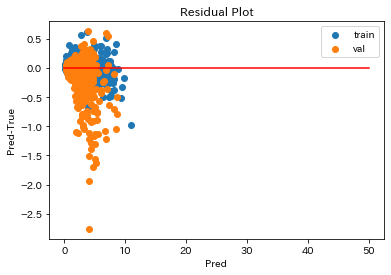

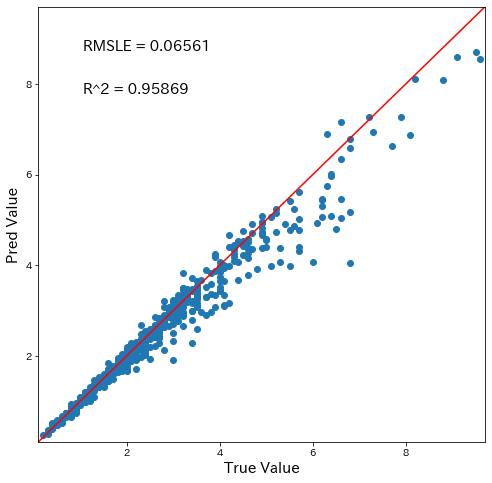

In [14]:
print("訓練データスコア")
get_eval_score(y4_train,extratrees_train_pred)
print("検証データスコア")
get_eval_score(y1_valid,extratrees_val_pred)
residual_plot(extratrees_train_pred,y4_train,extratrees_val_pred,y1_valid)

pred_df = pd.concat([y1_valid.reset_index(drop=True), pd.Series(extratrees_val_pred)], axis=1)
pred_df.columns = ['true', 'pred']
True_Pred_map(pred_df)

5.2.2 CO変数重要度の抽出・描画

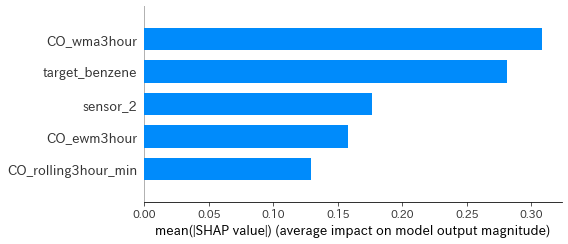

In [298]:
import shap
explainer=shap.TreeExplainer(extratrees_model)

shap_values=explainer.shap_values(X4_valid)

shap.summary_plot(
    shap_values=shap_values,
    features=X4_valid,
    plot_type="bar",
    max_display=5)

5.2.3 ベンゼン モデル作成(final model)

In [23]:
#benzene(part1)
train2=pd.read_csv('train2.csv')   
train2.date_time = pd.to_datetime(train2.date_time)
train2=train2.set_index('date_time')

CO_features = ['deg_C', 'relative_humidity', 'absolute_humidity', 'sensor_1','sensor_2', 'sensor_3', 'sensor_4', 'sensor_5']
benzene_features = ['deg_C', 'relative_humidity', 'absolute_humidity', 'sensor_1','sensor_2', 'sensor_3', 'sensor_4', 'sensor_5',\
      'benzene_shift1', 'benzene_shift2', 'benzene_rolling3hour','benzene_rolling10days','benzene_rolling3hour_min','benzene_rolling10days_min','benzene_rolling3hour_max',\
        'benzene_rolling10days_max', 'benzene_ewm3hour', 'benzene_ewm10days','benzene_rolling3hour_minmax', 'benzene_rolling10days_minmax','benzene_wma3hour','benzene_wma10days']
NOx_features = ['deg_C', 'relative_humidity', 'absolute_humidity', 'sensor_1','sensor_2', 'sensor_3', 'sensor_4', 'sensor_5','target_benzene','target_carbon_monoxide']


X5 = train2[benzene_features].copy()
y5 = train2.target_benzene.copy()


# 学習データを2010-03-10 18:00:00〜2010-12-01 00:00:00の期間としX_trainに入力する
X5_train = X5['2010-03-10 16:00:00' : '2010-12-01 00:00:00']
y5_train = y5['2010-03-10 16:00:00' : '2010-12-01 00:00:00']

# 検証データを2010-12-01 01:00:00以降としてとしてX_validに入力する
X5_valid = X5['2010-12-01 01:00:00' : ]
y5_valid = y5['2010-12-01 01:00:00' : ]



randomforest_model=RandomForestRegressor(random_state = random_state)
randomforest_model.fit(
    X5_train, y5_train
)
# 予測
randomforest_train_pred = randomforest_model.predict(X5_train)
randomforest_train_pred=relu(randomforest_train_pred)
randomforest_benzene_val_pred = randomforest_model.predict(X5_valid)
randomforest_benzene_val_pred=relu(randomforest_benzene_val_pred)
print("訓練データスコア")
get_eval_score(y5_train,randomforest_train_pred)
print("検証データスコア")
get_eval_score(y2_valid,randomforest_benzene_val_pred)
residual_plot(randomforest_train_pred,y5_train,randomforest_benzene_val_pred,y2_valid)

pred_df = pd.concat([y2_valid.reset_index(drop=True), pd.Series(randomforest_benzene_val_pred)], axis=1)
pred_df.columns = ['true', 'pred']
True_Pred_map(pred_df)

訓練データスコア
 MAE=0.3070241711579291
 MSE=0.19983591491099117
 MAPE=3.3145273199142955
 RMSE=0.4470301051506388
 RMSLE=0.034753467768047504
 R2=0.9965176990955475
検証データスコア
 MAE=0.807665317139001
 MSE=1.4990618677462881
 MAPE=9.73994302804077
 RMSE=1.2243618206013647
 RMSLE=0.09915886823441604
 R2=0.9737751332697173


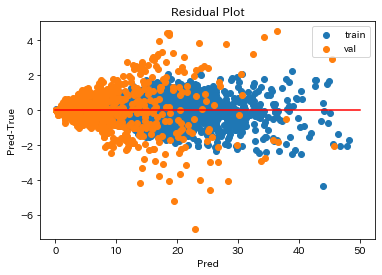

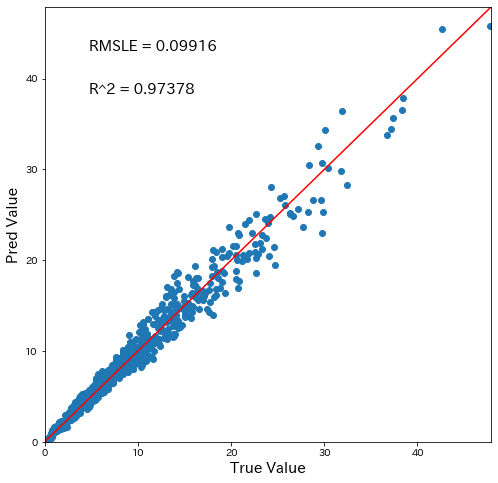

In [25]:
#benzene(part2)初期モデルに戻す
sample_submission=pd.read_csv(os.path.join(Input, "sample_submission.csv"))
train = pd.read_csv(os.path.join(Input, "train.csv"))
test = pd.read_csv(os.path.join(Input, "test.csv"))

train.date_time = pd.to_datetime(train.date_time)
train=train.set_index('date_time')


drop_date_range_rolling=pd.date_range('2010-03-10 18:00:00','2010-03-20 16:00:00',freq='H')
train=train.drop(drop_date_range_rolling)

#外れ値処理
train=train.drop(index=['2010/9/12 16:00','2010/10/26 18:00','2010/11/23 18:00','2010/11/23 19:00','2010/11/22 10:00',\
                        '2010/12/10 5:00','2010/12/10 7:00','2010/12/10 10:00','2010/10/26 18:00'])
# # #異常値処理
# drop_date_range_a=pd.date_range('2010-04-08 23:00:00','2010-04-10 00:00:00',freq='H')
# drop_date_range_b=pd.date_range('2010/05/25  19:00:00','2010/05/26  0:00:00',freq='H')
# drop_date_range_c=pd.date_range('2010/06/19  12:00:00','2010/06/21  03:00:00',freq='H')
# drop_date_range_d=pd.date_range('2010/08/26  00:00:00','2010/08/28  06:00:00',freq='H')
# drop_date_range_e=pd.date_range('2010/12/14  17:00:00','2010/12/17  19:00:00',freq='H')
# # train=train.drop(drop_date_range_a)
# train=train.drop(drop_date_range_b)
# # train=train.drop(drop_date_range_c)
# train=train.drop(drop_date_range_d)
# train=train.drop(drop_date_range_e)


#target:target_carbon_monoxide	target_benzene	target_nitrogen_oxides

CO_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides')]
benzene_features = ['deg_C', 'relative_humidity', 'absolute_humidity', 'sensor_1','sensor_2', 'sensor_3', 'sensor_4', 'sensor_5']
NOx_features = [feature for feature in train.columns if feature not in ('target_benzene','target_carbon_monoxide','target_nitrogen_oxides')]

    
X1 = train[CO_features].copy()
y1 = train.target_carbon_monoxide.copy()
X2 = train[benzene_features].copy()
y2 = train.target_benzene.copy()
X3 = train[NOx_features].copy()
y3 = train.target_nitrogen_oxides.copy()


# 学習データを2010-03-10 18:00:00〜2010-12-01 00:00:00の期間としX_trainに入力する
X1_train = X1['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y1_train = y1['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X2_train = X2['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y2_train = y2['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X3_train = X3['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y3_train = y3['2010-03-10 18:00:00' : '2010-12-01 00:00:00']

# 検証データを2010-12-01 01:00:00以降としてとしてX_validに入力する
X1_valid = X1['2010-12-01 01:00:00' : ]
y1_valid = y1['2010-12-01 01:00:00' : ]
X2_valid = X2['2010-12-01 01:00:00' : ]
y2_valid = y2['2010-12-01 01:00:00' : ]
X3_valid = X3['2010-12-01 01:00:00' : ]
y3_valid = y3['2010-12-01 01:00:00' : ]


randomforest_model=RandomForestRegressor(random_state = random_state)
randomforest_model.fit(
    X2_train, y2_train
)
# 予測
randomforest_train_pred = randomforest_model.predict(X2_train)
randomforest_train_pred=relu(randomforest_train_pred)
randomforest_benzene_val_pred = randomforest_model.predict(X2_valid)
randomforest_benzene_val_pred=relu(randomforest_benzene_val_pred)
print("訓練データスコア")
get_eval_score(y2_train,randomforest_train_pred)
print("検証データスコア")
get_eval_score(y2_valid,randomforest_benzene_val_pred)
residual_plot(randomforest_train_pred,y2_train,randomforest_benzene_val_pred,y2_valid)

pred_df = pd.concat([y2_valid.reset_index(drop=True), pd.Series(randomforest_benzene_val_pred)], axis=1)
pred_df.columns = ['true', 'pred']
True_Pred_map(pred_df)

5.2.4 ベンゼン変数重要度の抽出・描画

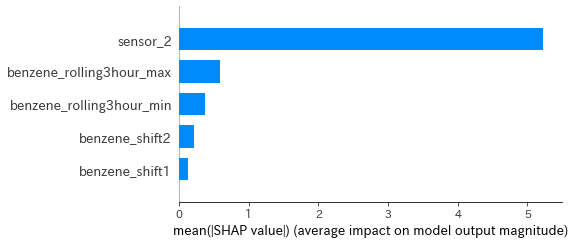

In [411]:
import shap
explainer=shap.TreeExplainer(randomforest_model)

shap_values=explainer.shap_values(X5_valid)

shap.summary_plot(
    shap_values=shap_values,
    features=X5_valid,
    plot_type="bar",
    max_display=5)

5.2.5 NOx モデル作成(final model)

In [19]:
#NOx(final)
#読み込み
train2=pd.read_csv('train2.csv')   
train2.date_time = pd.to_datetime(train2.date_time)
train2=train2.set_index('date_time')


CO_features = ['deg_C', 'relative_humidity', 'absolute_humidity', 'sensor_1','sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'target_benzene','target_nitrogen_oxides']
benzene_features = ['deg_C', 'relative_humidity', 'absolute_humidity', 'sensor_1','sensor_2', 'sensor_3', 'sensor_4', 'sensor_5']
NOx_features = ['deg_C', 'relative_humidity', 'absolute_humidity', 'sensor_1','sensor_2', 'sensor_3', 'sensor_4', 'sensor_5','target_benzene','target_carbon_monoxide',\
    'NOx_shift1','NOx_shift2','NOx_rolling3hour','NOx_rolling10days', 'NOx_rolling3hour_min', 'NOx_rolling10days_min','NOx_rolling3hour_max',\
       'NOx_rolling10days_max','NOx_ewm3hour', 'NOx_ewm10days', 'NOx_rolling3hour_minmax','NOx_rolling10days_minmax', 'NOx_wma3hour','NOx_wma10days']

X4 = train2[CO_features].copy()
y4 = train2.target_carbon_monoxide.copy()
X5 = train2[benzene_features].copy()
y5 = train2.target_benzene.copy()
X6 = train2[NOx_features].copy()
y6 = train2.target_nitrogen_oxides.copy()

# 学習データを2010-03-10 18:00:00〜2010-12-01 00:00:00の期間としX_trainに入力する
X4_train = X4['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y4_train = y4['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X5_train = X5['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y5_train = y5['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X6_train = X6['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y6_train = y6['2010-03-10 18:00:00' : '2010-12-01 00:00:00']

# 検証データを2010-12-01 01:00:00以降としてとしてX_validに入力する
X4_valid = X4['2010-12-01 01:00:00' : ]
y4_valid = y4['2010-12-01 01:00:00' : ]
X5_valid = X5['2010-12-01 01:00:00' : ]
y5_valid = y5['2010-12-01 01:00:00' : ]
X6_valid = X6['2010-12-01 01:00:00' : ]
y6_valid = y6['2010-12-01 01:00:00' : ]

#COを予測
import optuna
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'rmse',
        'lambda_l1': trial.suggest_loguniform('lambda_l1', 1e-8, 10.0),
        'lambda_l2': trial.suggest_loguniform('lambda_l2', 1e-8, 10.0),
        'num_leaves': trial.suggest_int('num_leaves', 2, 10),
        'feature_fraction': trial.suggest_uniform('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100)
    }
    
    trn_data = lgb.Dataset(X4_train, label=y4_train)
    val_data = lgb.Dataset(X4_valid, label=y4_valid)
    
    bst = lgb.train(params, trn_data, 10000, valid_sets = [trn_data, val_data], verbose_eval=-1, early_stopping_rounds = 20) 
    preds = bst.predict(X4_valid)
    pred_labels = np.rint(preds)
    
    RMSE = np.sqrt(mean_squared_error(y4_valid, pred_labels))
    rmsle=np.sqrt(mean_squared_log_error (y4_valid, preds))
    
    pruning_callback = optuna.integration.LightGBMPruningCallback(trial, 'rmsle')
    return rmsle
if __name__ == "__main__":
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=100, timeout=1200)

    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))
    print("  Params: ")
    for key, value in trial.params.items():
        print("{}: {}".format(key, value))
Best_trial = study.best_trial.params
Best_trial['metric']={'rmse'}
print('params:',Best_trial)
#Optunaで最適化されたパラメータ
params = Best_trial
trn_data = lgb.Dataset(X4_train, label=y4_train)
val_data = lgb.Dataset(X4_valid, label=y4_valid)
#LightGBMのモデル構築
gbm = lgb.train(params, trn_data, 10000, valid_sets = [trn_data, val_data], verbose_eval=-1, early_stopping_rounds = 10) 
 
#モデル評価用データで予測値出力
lgbm_CO_val_pred = gbm.predict(X4_valid)
lgbm_CO_val_pred=relu(lgbm_CO_val_pred)



#benzeneを予測
randomforest_model=RandomForestRegressor(random_state = random_state)
randomforest_model.fit(
    X5_train, y5_train
)
# 予測
randomforest_train_pred = randomforest_model.predict(X5_train)
randomforest_train_pred=relu(randomforest_train_pred)
randomforest_benzene_val_pred = randomforest_model.predict(X5_valid)
randomforest_benzene_val_pred=relu(randomforest_benzene_val_pred)



CO_features = ['deg_C', 'relative_humidity', 'absolute_humidity', 'sensor_1','sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'target_benzene','target_nitrogen_oxides']
benzene_features = ['deg_C', 'relative_humidity', 'absolute_humidity', 'sensor_1','sensor_2', 'sensor_3', 'sensor_4', 'sensor_5']
NOx_features = ['deg_C', 'relative_humidity', 'absolute_humidity', 'sensor_1','sensor_2', 'sensor_3', 'sensor_4', 'sensor_5','target_benzene','target_carbon_monoxide',\
    'NOx_shift1','NOx_shift2', 'NOx_rolling3hour', 'CO_rolling10days', 'NOx_rolling10days', 'NOx_rolling3hour_min', 'NOx_rolling10days_min','NOx_rolling3hour_max', 'NOx_rolling10days_max','NOx_ewm3hour', \
    'NOx_ewm10days', 'NOx_rolling3hour_minmax','NOx_rolling10days_minmax', 'NOx_wma3hour','NOx_wma10days']


X4 = train2[CO_features].copy()
y4 = train2.target_carbon_monoxide.copy()
X5 = train2[benzene_features].copy()
y5 = train2.target_benzene.copy()
X6 = train2[NOx_features].copy()
y6 = train2.target_nitrogen_oxides.copy()
# 学習データを2010-03-10 18:00:00〜2010-12-01 00:00:00の期間としX_trainに入力する
X4_train = X4['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y4_train = y4['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X5_train = X5['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y5_train = y5['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
X6_train = X6['2010-03-10 18:00:00' : '2010-12-01 00:00:00']
y6_train = y6['2010-03-10 18:00:00' : '2010-12-01 00:00:00']

# 検証データを2010-12-01 01:00:00以降としてとしてX_validに入力する
X4_valid = X4['2010-12-01 01:00:00' : ]
y4_valid = y4['2010-12-01 01:00:00' : ]
X5_valid = X5['2010-12-01 01:00:00' : ]
y5_valid = y5['2010-12-01 01:00:00' : ]
X6_valid = X6['2010-12-01 01:00:00' : ]
y6_valid = y6['2010-12-01 01:00:00' : ]


X6_valid['target_carbon_monoxide'] =lgbm_CO_val_pred.copy()
X6_valid['target_benzene'] =randomforest_benzene_val_pred.copy()

extratrees_model=ExtraTreesRegressor(n_estimators=100,bootstrap = True, random_state = random_state)
extratrees_model.fit(
    X6_train, y6_train
)
# 予測
extratrees_train_pred = extratrees_model.predict(X6_train)
extratrees_train_pred=relu(extratrees_train_pred)
extratrees_val_pred = extratrees_model.predict(X6_valid)
extratrees_val_pred=relu(extratrees_val_pred)


[I 2022-11-23 09:37:00,564] A new study created in memory with name: no-name-e302b00c-dbc9-4591-8abb-99661a2b8773
[I 2022-11-23 09:37:00,591] Trial 0 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.16543234030475115, 'lambda_l2': 9.377735398954472e-06, 'num_leaves': 5, 'feature_fraction': 0.9349974794175, 'bagging_fraction': 0.9412659327976328, 'bagging_freq': 5, 'min_child_samples': 5}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:00,611] Trial 1 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.11356084633838337, 'lambda_l2': 1.3234174321279942e-05, 'num_leaves': 7, 'feature_fraction': 0.7092951511641921, 'bagging_fraction': 0.5755205681728855, 'bagging_freq': 7, 'min_child_samples': 76}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:00,636] Trial 2 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.4755838306022628e-06, 'lambda_l2': 1.7947261606051217e-05, 'num_leaves': 8,

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] 

[I 2022-11-23 09:37:00,770] Trial 8 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 3.2076224147230175, 'lambda_l2': 0.15841646536706616, 'num_leaves': 8, 'feature_fraction': 0.8388771864102247, 'bagging_fraction': 0.546235064711335, 'bagging_freq': 3, 'min_child_samples': 46}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:00,791] Trial 9 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 2.9424247266659542e-05, 'lambda_l2': 8.516607796453342e-08, 'num_leaves': 8, 'feature_fraction': 0.6461053558359184, 'bagging_fraction': 0.7020735423657798, 'bagging_freq': 6, 'min_child_samples': 66}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:00,826] Trial 10 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.007720388327930591, 'lambda_l2': 0.0009144242377240557, 'num_leaves': 4, 'feature_fraction': 0.795821927936992, 'bagging_fraction': 0.4094625691692137, 'bagging_freq': 5, 'min_child_samp

[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more 

[I 2022-11-23 09:37:00,976] Trial 14 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.00034176835606491496, 'lambda_l2': 0.00021401942035024918, 'num_leaves': 4, 'feature_fraction': 0.7335582924993759, 'bagging_fraction': 0.43551729883836204, 'bagging_freq': 5, 'min_child_samples': 62}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:01,011] Trial 15 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.1660390819364186, 'lambda_l2': 5.698184474775451e-07, 'num_leaves': 6, 'feature_fraction': 0.4049816801976116, 'bagging_fraction': 0.6340411206940145, 'bagging_freq': 5, 'min_child_samples': 84}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:01,050] Trial 16 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0001795297173621439, 'lambda_l2': 8.796329529483467, 'num_leaves': 4, 'feature_fraction': 0.5472643482784323, 'bagging_fraction': 0.9903981773947174, 'bagging_freq': 7, 'min_child

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000863 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] 

[I 2022-11-23 09:37:01,160] Trial 19 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.00016210725277124118, 'lambda_l2': 0.015069550240646516, 'num_leaves': 4, 'feature_fraction': 0.5753713225099802, 'bagging_fraction': 0.9861160057862026, 'bagging_freq': 6, 'min_child_samples': 50}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:01,202] Trial 20 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 3.3778747660008907e-06, 'lambda_l2': 0.007384872066439988, 'num_leaves': 3, 'feature_fraction': 0.8551448153218804, 'bagging_fraction': 0.5057018656695697, 'bagging_freq': 5, 'min_child_samples': 35}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:01,240] Trial 21 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 4.6322380942956674e-08, 'lambda_l2': 0.00010866682527460569, 'num_leaves': 5, 'feature_fraction': 0.9956599443270575, 'bagging_fraction': 0.7644823249471343, 'bagging_freq': 3, 'min

[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000509 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are 

[I 2022-11-23 09:37:01,351] Trial 24 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 2.732552271967005e-08, 'lambda_l2': 0.00013716172949685787, 'num_leaves': 3, 'feature_fraction': 0.9981334921644598, 'bagging_fraction': 0.6343053070429574, 'bagging_freq': 4, 'min_child_samples': 19}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:01,392] Trial 25 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.005993030043636963, 'lambda_l2': 4.849068595475077e-05, 'num_leaves': 5, 'feature_fraction': 0.9493976847103797, 'bagging_fraction': 0.760449562705821, 'bagging_freq': 2, 'min_child_samples': 40}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:01,430] Trial 26 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0010718592571691478, 'lambda_l2': 2.8985976792235994e-07, 'num_leaves': 3, 'feature_fraction': 0.4883169399992101, 'bagging_fraction': 0.9337921742828506, 'bagging_freq': 6, 'min_c

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000422 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warnin

[I 2022-11-23 09:37:01,546] Trial 29 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0007389901075824463, 'lambda_l2': 3.190688409581471e-06, 'num_leaves': 6, 'feature_fraction': 0.7861666912183342, 'bagging_fraction': 0.8441567434915471, 'bagging_freq': 2, 'min_child_samples': 5}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:01,627] Trial 30 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 2.9329937660132484e-05, 'lambda_l2': 1.0244286627218672e-08, 'num_leaves': 2, 'feature_fraction': 0.7095107293009814, 'bagging_fraction': 0.945343331311437, 'bagging_freq': 4, 'min_child_samples': 28}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:01,677] Trial 31 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.018965654729920164, 'lambda_l2': 3.806085643849975e-06, 'num_leaves': 7, 'feature_fraction': 0.9024775810196597, 'bagging_fraction': 0.6426929713341262, 'bagging_freq': 1, 'min_ch

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000443 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] 

[I 2022-11-23 09:37:01,752] Trial 33 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 4.8130221155934876e-05, 'lambda_l2': 4.014322367093709e-06, 'num_leaves': 7, 'feature_fraction': 0.7006564626045994, 'bagging_fraction': 0.9195141114689569, 'bagging_freq': 2, 'min_child_samples': 27}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:01,788] Trial 34 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.03488292590523574, 'lambda_l2': 1.018208653599134e-08, 'num_leaves': 9, 'feature_fraction': 0.7379031277612264, 'bagging_fraction': 0.8378652890517577, 'bagging_freq': 1, 'min_child_samples': 13}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:01,824] Trial 35 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.0591787625693616e-06, 'lambda_l2': 0.013452197302391056, 'num_leaves': 4, 'feature_fraction': 0.5980600554960074, 'bagging_fraction': 0.9983405104037562, 'bagging_freq': 5, 'min_ch

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000409 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] 

[I 2022-11-23 09:37:01,935] Trial 38 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 2.5198695022633903e-07, 'lambda_l2': 0.0007829146760365922, 'num_leaves': 6, 'feature_fraction': 0.8829192470002829, 'bagging_fraction': 0.9592471310235763, 'bagging_freq': 3, 'min_child_samples': 100}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:01,976] Trial 39 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0019116691689689304, 'lambda_l2': 0.050219504673696964, 'num_leaves': 5, 'feature_fraction': 0.6648130741530105, 'bagging_fraction': 0.8020939068414452, 'bagging_freq': 7, 'min_child_samples': 23}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:02,015] Trial 40 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 7.720293628488284e-07, 'lambda_l2': 1.101032296463925e-05, 'num_leaves': 3, 'feature_fraction': 0.48496646950097805, 'bagging_fraction': 0.49663103973578393, 'bagging_freq': 4, 'mi

[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000641 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are 

[I 2022-11-23 09:37:02,138] Trial 43 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.003226494208604925, 'lambda_l2': 4.720446171558585e-05, 'num_leaves': 2, 'feature_fraction': 0.914500012975102, 'bagging_fraction': 0.580458514837433, 'bagging_freq': 6, 'min_child_samples': 7}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:02,174] Trial 44 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.4991834909168947e-05, 'lambda_l2': 0.6760332357009899, 'num_leaves': 2, 'feature_fraction': 0.8946353432572324, 'bagging_fraction': 0.653724032355014, 'bagging_freq': 4, 'min_child_samples': 17}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:02,217] Trial 45 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.00011230436199604463, 'lambda_l2': 0.00029434480194770224, 'num_leaves': 2, 'feature_fraction': 0.9975781400111455, 'bagging_fraction': 0.6637331097796602, 'bagging_freq': 5, 'min_child_

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000385 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] 

[I 2022-11-23 09:37:02,327] Trial 48 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0008042554271909944, 'lambda_l2': 4.5694786448132e-06, 'num_leaves': 6, 'feature_fraction': 0.827282717991868, 'bagging_fraction': 0.90988157065223, 'bagging_freq': 1, 'min_child_samples': 6}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:02,363] Trial 49 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0010756871869591845, 'lambda_l2': 5.285728645139644e-08, 'num_leaves': 7, 'feature_fraction': 0.8045411150232256, 'bagging_fraction': 0.8679517410975697, 'bagging_freq': 7, 'min_child_samples': 15}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:02,407] Trial 50 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.4462773132540228e-05, 'lambda_l2': 2.3892719101137935e-06, 'num_leaves': 9, 'feature_fraction': 0.7428095038643441, 'bagging_fraction': 0.6052705247107385, 'bagging_freq': 4, 'min_child

[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000504 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are 

[I 2022-11-23 09:37:02,524] Trial 53 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.28355087710362387, 'lambda_l2': 1.6346294463409536e-08, 'num_leaves': 10, 'feature_fraction': 0.7886397485859431, 'bagging_fraction': 0.845392392031951, 'bagging_freq': 1, 'min_child_samples': 12}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:02,563] Trial 54 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 5.7469170003646057e-05, 'lambda_l2': 4.288847488408173e-06, 'num_leaves': 8, 'feature_fraction': 0.7004204531356738, 'bagging_fraction': 0.914552839166064, 'bagging_freq': 2, 'min_child_samples': 26}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:02,609] Trial 55 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.00032038116510225636, 'lambda_l2': 4.8021228571742584e-08, 'num_leaves': 8, 'feature_fraction': 0.6813483647099181, 'bagging_fraction': 0.96045391445029, 'bagging_freq': 2, 'min_ch

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000406 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warnin

[I 2022-11-23 09:37:02,729] Trial 58 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.19092681914776388, 'lambda_l2': 1.1824622456793482e-06, 'num_leaves': 10, 'feature_fraction': 0.6257765521424763, 'bagging_fraction': 0.9999854487183347, 'bagging_freq': 5, 'min_child_samples': 35}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:02,770] Trial 59 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.5053449868372146, 'lambda_l2': 4.588451619246021, 'num_leaves': 9, 'feature_fraction': 0.7583470448888137, 'bagging_fraction': 0.9770871175798665, 'bagging_freq': 1, 'min_child_samples': 9}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:02,814] Trial 60 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.4139315777348017e-07, 'lambda_l2': 0.0022126141409013595, 'num_leaves': 4, 'feature_fraction': 0.5924918786299045, 'bagging_fraction': 0.9269587578734516, 'bagging_freq': 3, 'min_child_sa

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000507 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no

[I 2022-11-23 09:37:02,930] Trial 63 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 3.174870530417053e-07, 'lambda_l2': 2.0404941529903694e-05, 'num_leaves': 6, 'feature_fraction': 0.9715282261952422, 'bagging_fraction': 0.9459892712573066, 'bagging_freq': 3, 'min_child_samples': 44}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:02,972] Trial 64 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 8.982917145821378e-08, 'lambda_l2': 0.0480664394110675, 'num_leaves': 5, 'feature_fraction': 0.9310994233048281, 'bagging_fraction': 0.8065268784684893, 'bagging_freq': 5, 'min_child_samples': 39}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:03,015] Trial 65 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 7.723796786555133e-07, 'lambda_l2': 0.09308709110302103, 'num_leaves': 5, 'feature_fraction': 0.6655657634935294, 'bagging_fraction': 0.7799928388569641, 'bagging_freq': 7, 'min_child

[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000684 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are 

[I 2022-11-23 09:37:03,100] Trial 67 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 6.53470992986791e-07, 'lambda_l2': 0.026041098529091918, 'num_leaves': 4, 'feature_fraction': 0.5086162852229704, 'bagging_fraction': 0.7454740602867864, 'bagging_freq': 4, 'min_child_samples': 76}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:03,149] Trial 68 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.0535087572769495e-08, 'lambda_l2': 2.5663921217146902e-05, 'num_leaves': 5, 'feature_fraction': 0.9738434759270332, 'bagging_fraction': 0.46050154773828783, 'bagging_freq': 3, 'min_child_samples': 54}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:03,192] Trial 69 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 3.473899555025096e-07, 'lambda_l2': 1.1210484802425777e-05, 'num_leaves': 6, 'feature_fraction': 0.42935025556615036, 'bagging_fraction': 0.48813463843405097, 'bagging_freq': 3, 'm

[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stoppe

[I 2022-11-23 09:37:03,315] Trial 72 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.01415413175753848, 'lambda_l2': 1.894695267151922e-06, 'num_leaves': 8, 'feature_fraction': 0.8127261444003543, 'bagging_fraction': 0.6824288994728755, 'bagging_freq': 1, 'min_child_samples': 17}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:03,364] Trial 73 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.005079221510420474, 'lambda_l2': 1.9780517621287237e-07, 'num_leaves': 7, 'feature_fraction': 0.8521077922538529, 'bagging_fraction': 0.6056073252614652, 'bagging_freq': 2, 'min_child_samples': 9}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:03,404] Trial 74 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.083219759261234, 'lambda_l2': 6.747511329642635e-08, 'num_leaves': 10, 'feature_fraction': 0.7618275543300836, 'bagging_fraction': 0.823503049778961, 'bagging_freq': 1, 'min_child_sa

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000729 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warnin

[I 2022-11-23 09:37:03,483] Trial 76 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 6.487122007753115e-05, 'lambda_l2': 2.3569420483948036e-06, 'num_leaves': 8, 'feature_fraction': 0.7677996930982799, 'bagging_fraction': 0.9145795891807851, 'bagging_freq': 2, 'min_child_samples': 19}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:03,525] Trial 77 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.1484894349270567, 'lambda_l2': 6.994723132942197e-07, 'num_leaves': 8, 'feature_fraction': 0.7838391112830084, 'bagging_fraction': 0.8675713806753903, 'bagging_freq': 1, 'min_child_samples': 7}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:03,563] Trial 78 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.0003631750976897725, 'lambda_l2': 3.976310005144834e-08, 'num_leaves': 9, 'feature_fraction': 0.6901132431624051, 'bagging_fraction': 0.8270904446139128, 'bagging_freq': 2, 'min_chil

[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Early stopping, best iteration is:
[1]	training's rmse: 1.72455	valid_1's rmse: 2.14695
[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000914 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the spl

[I 2022-11-23 09:37:03,683] Trial 81 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 9.897143315699076, 'lambda_l2': 1.3656568411607727e-06, 'num_leaves': 10, 'feature_fraction': 0.6251245005498335, 'bagging_fraction': 0.9567099236469251, 'bagging_freq': 1, 'min_child_samples': 32}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:03,726] Trial 82 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 0.7710899838167844, 'lambda_l2': 2.446901958709594e-08, 'num_leaves': 9, 'feature_fraction': 0.6315311174444835, 'bagging_fraction': 0.9739234904786969, 'bagging_freq': 1, 'min_child_samples': 36}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:03,762] Trial 83 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 4.254431273610904, 'lambda_l2': 1.4927260961302822e-08, 'num_leaves': 10, 'feature_fraction': 0.6803645133304038, 'bagging_fraction': 0.9815496463556269, 'bagging_freq': 1, 'min_child_sa

[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that m

[I 2022-11-23 09:37:03,887] Trial 86 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 4.764449944834517e-06, 'lambda_l2': 8.15749872164699e-08, 'num_leaves': 9, 'feature_fraction': 0.5650748047018601, 'bagging_fraction': 0.932983582741947, 'bagging_freq': 2, 'min_child_samples': 33}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:03,966] Trial 87 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 4.010305165896772e-08, 'lambda_l2': 4.5238557252739617e-08, 'num_leaves': 4, 'feature_fraction': 0.7215075792620923, 'bagging_fraction': 0.9676220258883499, 'bagging_freq': 3, 'min_child_samples': 65}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:04,029] Trial 88 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.8053342212537754e-07, 'lambda_l2': 0.0005926476623041342, 'num_leaves': 4, 'feature_fraction': 0.7497498176175672, 'bagging_fraction': 0.8828894970193305, 'bagging_freq': 3, 'min_c

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000388 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warnin

[I 2022-11-23 09:37:04,067] Trial 89 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 5.306417292925607e-08, 'lambda_l2': 3.1682346352126034, 'num_leaves': 6, 'feature_fraction': 0.5843273278943623, 'bagging_fraction': 0.9465778608282047, 'bagging_freq': 3, 'min_child_samples': 58}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:04,108] Trial 90 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 8.823454708258933e-08, 'lambda_l2': 0.28584121618195424, 'num_leaves': 5, 'feature_fraction': 0.9177505139797206, 'bagging_fraction': 0.9818216301567987, 'bagging_freq': 5, 'min_child_samples': 38}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:04,157] Trial 91 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 4.4705994298347024e-07, 'lambda_l2': 0.07621973766398057, 'num_leaves': 5, 'feature_fraction': 0.6526040430064809, 'bagging_fraction': 0.9479111467099751, 'bagging_freq': 5, 'min_child_s

[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more 

[I 2022-11-23 09:37:04,277] Trial 94 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 5.592159634688017e-07, 'lambda_l2': 0.001480593130056547, 'num_leaves': 4, 'feature_fraction': 0.5014157903079592, 'bagging_fraction': 0.7848740547507794, 'bagging_freq': 4, 'min_child_samples': 69}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:04,318] Trial 95 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.1339556917966163e-08, 'lambda_l2': 0.02024847288535389, 'num_leaves': 5, 'feature_fraction': 0.9797153965097866, 'bagging_fraction': 0.7251034610075177, 'bagging_freq': 3, 'min_child_samples': 54}. Best is trial 0 with value: 0.6172048919370051.
[I 2022-11-23 09:37:04,359] Trial 96 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 2.763990911038008e-07, 'lambda_l2': 0.05275073132869384, 'num_leaves': 5, 'feature_fraction': 0.43835358212073783, 'bagging_fraction': 0.43071619746773887, 'bagging_freq': 3, 'min_chi

[LightGBM] [Info] Number of positive: 5823, number of negative: 0
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000382 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are 

[I 2022-11-23 09:37:04,479] Trial 99 finished with value: 0.6172048919370051 and parameters: {'lambda_l1': 1.763300626368279e-08, 'lambda_l2': 0.026086615271564105, 'num_leaves': 6, 'feature_fraction': 0.4126226920068982, 'bagging_fraction': 0.532096482625002, 'bagging_freq': 7, 'min_child_samples': 43}. Best is trial 0 with value: 0.6172048919370051.


[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000385 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5823, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Info] Start training from score 34.539576
[LightGBM] [Info] [binary:BoostFromScore]: pavg=1.000000 -> initscore=34.539576
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warnin


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


訓練データスコア
 MAE=3.2202306371286276
 MSE=51.62473904842858
 MAPE=1.849358555056104
 RMSE=7.185035772244184
 RMSLE=0.03251541734933028
 R2=0.9983549223184329
検証データスコア
 MAE=13.702358858858865
 MSE=479.65225696246324
 MAPE=4.340112305811948
 RMSE=21.900964749582684
 RMSLE=0.06617770181188264
 R2=0.9898169651268143


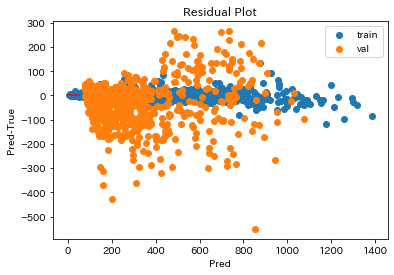

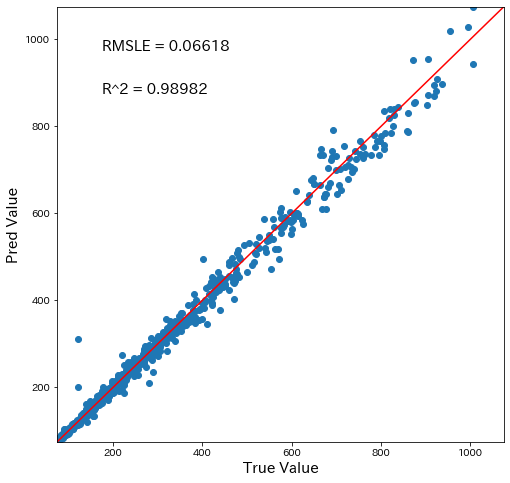

In [20]:
print("訓練データスコア")
get_eval_score(y6_train,extratrees_train_pred)
print("検証データスコア")
get_eval_score(y6_valid,extratrees_val_pred)
residual_plot(extratrees_train_pred,y6_train,extratrees_val_pred,y3_valid)

pred_df = pd.concat([y6_valid.reset_index(drop=True), pd.Series(extratrees_val_pred)], axis=1)
pred_df.columns = ['true', 'pred']
True_Pred_map(pred_df)


5.2.6 NOx変数重要度の抽出・描画

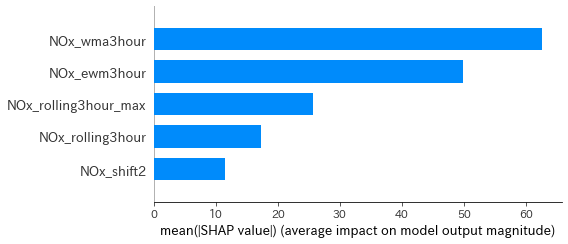

In [456]:
import shap
explainer=shap.TreeExplainer(extratrees_model)

shap_values=explainer.shap_values(X6_valid)

shap.summary_plot(
    shap_values=shap_values,
    features=X6_valid,
    plot_type="bar",
    max_display=5)

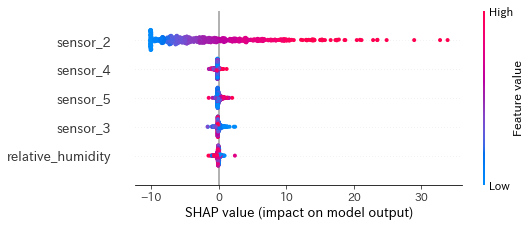

In [ ]:
shap.summary_plot(
    shap_values=shap_values,
    features=X3_valid,
    plot_type="dot",
    max_display=5)

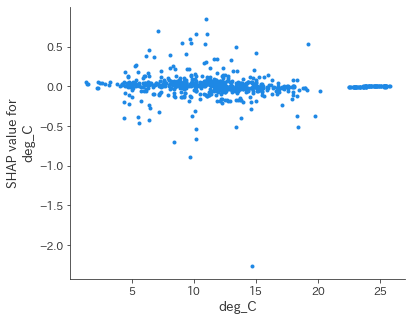

In [ ]:
shap.dependence_plot(
    ind="deg_C",
    interaction_index=None,
    shap_values=shap_values,
    features=X1_valid,
)

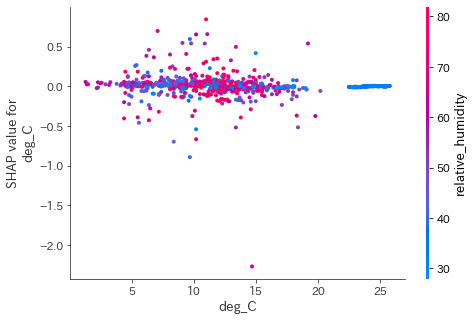

In [ ]:
shap.dependence_plot(
    ind="deg_C",
    interaction_index="relative_humidity",
    shap_values=shap_values,
    features=X1_valid,
)

In [ ]:
shap.initjs()
row_index=X1_valid.index.get_loc('2010-12-31 20:00:00')
shap.force_plot(
    base_value=explainer.expected_value,
    shap_values=shap_values[row_index,:],
    features=X1_valid.iloc[row_index,:])

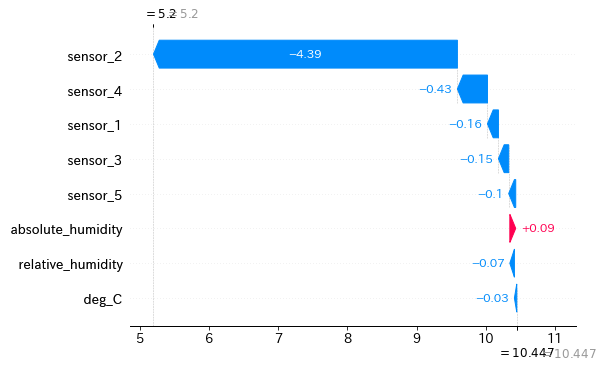

In [ ]:
row_index=X1_valid.index.get_loc('2010-12-31 20:00:00')
shap.plots._waterfall.waterfall_legacy(
    expected_value=explainer.expected_value[0],
    shap_values=shap_values[row_index,:],
    features=X1_train.iloc[row_index,:])